# 📊 Analyst Dashboard × MBA 563 · 564A · 564B
### One working tool, every course concept

This notebook does two things at once:

1. **Part 1 — The Dashboard** (your original code, unchanged): pulls live macro data from FRED, price action from Yahoo Finance, and sentiment from CNN, then renders and saves a daily markdown report. This part *is* Module 4 in production.
2. **Part 2 — The Analytics Lab**: feeds the same market data through the rest of the MBA 563 toolkit — pandas ETL/EDA (M2), SQL storage & queries (M3), the ML workflow (M5), regression (M6), classification (M7), and clustering (M8).
3. **Part 3 — The 564 Lab**: causal (DiD), predictive (Ridge/Lasso/RF/XGBoost in dollars), text (VADER), segmentation/CLV, process mining, digit forensics, automation, and governance — every 564A/564B module on the same data.
4. **Part 4 — The FIN 575 Lab**: the asset-pricing layer — CAPM/3-factor alpha·beta·R² per asset, low-R² diversification flags, cross-sectional momentum with the over/under-reaction test, sentiment wired into the forecasting models, a signal-committee stance per asset with turnover/churn measured, and the implied-terminal-growth smell test.

Throughout, **📘 checkpoint cells** map what the code is doing to the course concept it demonstrates.

## 🗺️ Concept Map — where each module lives

| Module | Concept | Where in this notebook |
|---|---|---|
| **M1** Mindset | FACT, counterfactuals, survivorship, logic, wrong metric | The next cell, plus the flag-logic checkpoint before the dashboard render |
| **M2** Python ETL/EDA | read → subset → rename → derive → outliers → corr → groupby | Lab cells L2–L3 |
| **M3** SQL & Databases | store/get/analyze split, schemas, JOINs, filter-before-pull | Lab cell L4 |
| **M4** APIs | 3-step workflow, loops, rate limits, try/except, key security | Part 1, Cells 1–5 (annotated) |
| **M5** ML Workflow | the 5-step skeleton, stats vs ML, encoding, train/test | Lab checkpoint before L5; skeleton used in L5–L8 |
| **M6** Regression | coefficients + p-values + R², confounding, trees | Lab cells L5–L6 |
| **M7** Classification | logit / tree / KNN, confusion matrix, 5 metrics | Lab cell L7 |
| **M8** Clustering | K-Means vs DBSCAN, elbow/silhouette, naming clusters, PCA | Lab cell L8 |
| **FDP** Capstone | rubric mapping of this very notebook | Capstone checkpoint |
| **564A/B** | causal · predictive · text · segmentation · process · forensics · automation · governance | Part 3, cells A1–A4, B1–B4 |
| **FIN 575** | factor regressions · momentum · sentiment-as-signal · stances+turnover · implied growth | Part 4, cells F1–F5 |

> **How to run:** Part 1 needs a `FRED_API_KEY` in a `.env` file (Cell 1 diagnoses any key problems). Part 2 needs internet access to Yahoo Finance — run Lab cell L0 (installs pandas/sklearn/statsmodels), then L1, then everything downstream is deterministic.


## 📘 Module 1 Checkpoint — The Analytics Mindset (read before trusting any dashboard)

**FACT** — every analytics effort is: **F**rame a question (3% of effort) → **A**ssemble data (**80%**) → **C**alculate (10%) → **T**ell (7%). Notice this notebook's proportions match: most of the code below is *assembly* (fetchers, parsers, cleaners); the "analysis" is a thin final layer. The goal of the whole pipeline is an **actionable insight**, not a number.

**The Three Nesses** this project runs on: *inquisitiveness* (why do I check 30 tickers manually when an API can?), *experimentativeness* (thresholds in the flag functions are tweakable hypotheses), and *stickitytuityness* (see the retry logic and key-diagnostics — determination, encoded).

**Moneyball logic applies here.** The Oakland A's couldn't out-spend the Yankees, so they closed the *evaluation* gap instead — replacing subjective scouting with objective metrics (hiring DePodesta to do it). A dashboard is the same move for a solo analyst: replace vibes-based market reads with measured signals.

**But hold the counterfactual thinking.** Every "signal" below is a *correlation*, and Module 1 says to check four causal structures before believing any of them. Take "inverted yield curve → recession":
- **Hypothesis:** inversion causes/predicts recession
- **Confounding:** Fed tightening drives *both* the inversion and the slowdown
- **Mediation:** inversion → tighter bank lending → recession (the effect flows through a middleman)
- **Reverse causation:** recession *expectations* invert the curve (markets pricing in cuts)

**Survivorship bias is baked into this dashboard's design** — and it's worth knowing. `SP500_TOP13` tracks today's *winners*. Like the WWII bombers (armor where the returning planes have **no** bullet holes — the ones hit elsewhere never came back), a top-13 list systematically excludes every company that fell out of it. Any pattern found in these tickers describes survivors, not stocks in general.

**The 2-4-8 trap:** if you believe "RSI > 70 means a pullback is coming," don't just recall times it worked — confirmation bias tests only confirming cases. Go look for overbought readings that kept climbing.

**Formal logic, dashboard edition.** Suppose your rule is *"if I buy, then RSI < 70."* To audit your own trades, check: trades you **bought** (modus ponens — was RSI < 70?) and days where **RSI ≥ 70** (modus tollens — did you buy anyway?). Checking days with RSI = 65 (affirming the consequent) or days you didn't buy (denying the antecedent) can never reveal a violation — both are invalid forms.

**And the two quotes to keep taped to the monitor** *(The Data or the Hunch)*: both analytics and intuition have a low validity ceiling — but only one of them **knows** the ceiling is there. And data can make overconfidence *worse* when you get hooked on the wrong **metric** — which is exactly why the flag functions in Cell 6 should be read as heuristics, not oracles.


---
# PART 1 — The Dashboard *(original code, unchanged)*

## 📘 Module 4 Checkpoint — APIs: why this part exists

APIs let computers talk to computers via URLs. They **simplify workflows** (this notebook replaces ~30 browser tabs), **keep data safe** (FRED grants access without handing you their database), and **monetize data** (the API key meters usage). Unlike SQL, **there is no standard API language — reading the documentation is *the* skill**: FRED wants `series_id`/`api_key`/`limit` parameters, Yahoo wants `interval`/`range`, CNN wants a browser User-Agent. Three APIs, three dialects, one pattern:

> **The 3-step workflow: (1) build the URL → (2) `requests.get()` → (3) parse the JSON.** Every fetcher below is this, wearing different clothes. *(An SDK, like Module 4's `finnhub-python`, would wrap steps 1–2 — this notebook goes raw for full control.)*

**Key security (Module 4's three tiers):** the key lives in a `.env` file loaded via `python-dotenv` — tier two of key-in-code < **key-in-env-file** < OAuth/bearer tokens. Never hardcode a key in a notebook you might share.


In [1]:
!pip install requests python-dotenv

In [2]:
# ── CELL 1 — IMPORTS & ENVIRONMENT ─────────────────────
# No pandas/numpy/yfinance — uses pure requests + stdlib only.
# No local LLM — this version fetches and PRESENTS data only.
from dotenv import load_dotenv, find_dotenv
import os, requests, json, time, math
from datetime import datetime
from pathlib import Path
from IPython.display import Markdown, display

# find_dotenv() searches upward from the current working directory and
# reports exactly WHICH .env file was found — removes all path guesswork.
ENV_PATH = find_dotenv(usecwd=True)
load_dotenv(ENV_PATH, override=True)

# Scrub quotes/whitespace that commonly sneak into .env files.
FRED_KEY = (os.getenv("FRED_API_KEY") or "").strip().strip('"').strip("'")

# FRED requires exactly 32 lowercase alphanumeric characters.
KEY_OK = len(FRED_KEY) == 32 and FRED_KEY.isalnum() and FRED_KEY.islower()

SP500_TOP13 = ["AAPL","MSFT","NVDA","AMZN","GOOGL","META","TSLA","BRK-B","AVGO","JPM","LLY","XOM","UNH"]
ASSETS      = SP500_TOP13 + ["BTC-USD", "GC=F"]  # GC=F = Gold futures

print(f".env file used: {ENV_PATH or '✗ NO .env FILE FOUND'}")
if KEY_OK:
    print(f"✓ Key valid format: {FRED_KEY[:4]}...{FRED_KEY[-4:]} (32 chars)")
elif not FRED_KEY:
    print("✗ FRED_API_KEY not set in that .env file.")
    print("  Add a line (no quotes, no spaces):  FRED_API_KEY=your32charkey")
else:
    print(f"✗ Key format invalid — {len(FRED_KEY)} chars, need 32 lowercase alphanumeric.")
    print(f"  Loaded value looks like: {FRED_KEY[:4]}...{FRED_KEY[-4:] if len(FRED_KEY) >= 8 else ''}")
    has_upper = any(c.isupper() for c in FRED_KEY)
    has_space = any(c.isspace() for c in FRED_KEY)
    non_alnum = [c for c in FRED_KEY if not c.isalnum()]
    if has_upper:  print("  → contains UPPERCASE letters (FRED keys are all lowercase)")
    if has_space:  print("  → contains internal whitespace")
    if non_alnum:  print(f"  → contains non-alphanumeric chars: {non_alnum[:5]}")
    print("  Fix the key in the .env file above, then re-run this cell.")

.env file used: C:\Users\hasan\OneDrive\Desktop\z13-analyst\.env
✓ Key valid format: 6e95...5ef0 (32 chars)


## 📘 Module 4 Checkpoint — the fetchers = production-grade loop hygiene

Module 4's six-step loop discipline, all present in the next cell:
- **Rate limits & retries** → `time.sleep(delay)` between attempts, `retries=3` (loop tip: *plan for errors*)
- **Status updates** → the `⚠ retrying...` prints (loop tip: *print progress; silent loops feel frozen*)
- **Exception handling** → graceful `raise` with the series id and HTTP code, so one bad series identifies itself
- **Pull only what you need** → `limit=1` (or `limit=n` for deltas) asks the *server* to truncate — Module 3's "filter before pulling" lesson, applied at the API layer

`fetch_fred_delta` also quietly does Module 2-style **data cleaning at ingestion**: FRED marks missing values as `"."`, and the fetcher filters them before computing deltas — real-world data always has fake nulls (IMDB used `"\N"`).


In [3]:
# ── CELL 2 — FRED FETCHERS ──────────────────────────────

def fetch_fred(series_id, retries=3, delay=5):
    url = (f"https://api.stlouisfed.org/fred/series/observations"
           f"?series_id={series_id}&api_key={FRED_KEY}"
           f"&sort_order=desc&limit=1&file_type=json")
    for attempt in range(retries):
        data = requests.get(url, timeout=10).json()
        if "observations" in data:
            val = data["observations"][0]["value"]
            return float(val) if val != "." else None
        code = data.get("error_code", "?")
        msg  = data.get("error_message", "?")
        if code == 500 and attempt < retries - 1:
            print(f"  ⚠ {series_id}: server error, retrying in {delay}s... ({attempt+1}/{retries})")
            time.sleep(delay)
        else:
            raise KeyError(f"{series_id} failed [HTTP {code}]: {msg}")


def fetch_fred_delta(series_id, n=7, retries=3, delay=5):
    # Fetch last n obs, return (latest_value, change_vs_oldest).
    # n=7 for daily series captures ~5 trading days of delta.
    url = (f"https://api.stlouisfed.org/fred/series/observations"
           f"?series_id={series_id}&api_key={FRED_KEY}"
           f"&sort_order=desc&limit={n}&file_type=json")
    for attempt in range(retries):
        data = requests.get(url, timeout=10).json()
        if "observations" in data:
            obs = [o for o in data["observations"] if o["value"] != "."]
            if not obs: return None, None
            latest = float(obs[0]["value"])
            delta  = round(latest - float(obs[-1]["value"]), 4) if len(obs) > 1 else None
            return latest, delta
        code = data.get("error_code", "?")
        msg  = data.get("error_message", "?")
        if code == 500 and attempt < retries - 1:
            print(f"  ⚠ {series_id}: server error, retrying in {delay}s... ({attempt+1}/{retries})")
            time.sleep(delay)
        else:
            raise KeyError(f"{series_id} failed [HTTP {code}]: {msg}")


def d(delta, unit=""):
    if delta is None: return "n/a"
    return f"{'+' if delta >= 0 else ''}{delta}{unit}"


def arrow(delta):
    # Direction glyph for tables — ▲ up, ▼ down, — flat/none.
    if delta is None: return "—"
    if delta > 0: return "▲"
    if delta < 0: return "▼"
    return "→"


print("✓ FRED fetchers ready")

✓ FRED fetchers ready


## 📘 Checkpoint — the pull cell: fail fast, label everything

Two habits worth stealing: the **hard stop** (`raise RuntimeError` if the key is bad — preventing 27 doomed API calls is the grown-up version of try/except), and **readable naming** (`dff` → *Effective Fed Funds Rate* via inline comments — Module 2's `rename()` philosophy: `cdmanipulation` helps nobody at 2 a.m., and neither does an unlabeled `DTWEXAFEGS`).


In [4]:
# ── CELL 3 — FRED DATA PULL ─────────────────────────────
# Gold price is NOT fetched here — it comes from GC=F via Yahoo in Cell 4.
# DTWEXBGS discontinued 2020 — using DTWEXAFEGS as active replacement.

# Hard stop if Cell 1 flagged the key — prevents 27 doomed API calls.
if not KEY_OK:
    raise RuntimeError(
        "FRED_API_KEY is missing or malformed — see Cell 1 output for the "
        "exact problem and which .env file was loaded. Fix it, re-run Cell 1, "
        "then re-run this cell."
    )

print("Fetching FRED data...")

# ── LIQUIDITY & DOLLAR  (daily) ──────────────────────────
dff,        dff_d   = fetch_fred_delta("DFF")           # Effective Fed Funds Rate
usd,        usd_d   = fetch_fred_delta("DTWEXAFEGS")    # USD Trade-Weighted Index
rrp,        rrp_d   = fetch_fred_delta("RRPONTSYD")     # Overnight Reverse Repos

# ── YIELDS & REAL RATES  (daily) ─────────────────────────
dgs2,       dgs2_d  = fetch_fred_delta("DGS2")          # 2-Year Treasury
dgs10,      dgs10_d = fetch_fred_delta("DGS10")         # 10-Year Treasury
t10y2y,     yc2_d   = fetch_fred_delta("T10Y2Y")        # Yield Curve 10Y-2Y
t10y3m,     yc3m_d  = fetch_fred_delta("T10Y3M")        # Yield Curve 10Y-3M
dfii10,     real_d  = fetch_fred_delta("DFII10")        # 10Y TIPS Real Rate
t10yie,     be10_d  = fetch_fred_delta("T10YIE")        # 10Y Breakeven Inflation
t5yifr,     fwd_d   = fetch_fred_delta("T5YIFR")        # 5Y5Y Forward Inflation

# ── RISK, CREDIT & VOLATILITY  (daily) ───────────────────
vix,        vix_d   = fetch_fred_delta("VIXCLS")        # CBOE VIX
gvz,        gvz_d   = fetch_fred_delta("GVZCLS")        # CBOE Gold VIX
hyoas,      hy_d    = fetch_fred_delta("BAMLH0A0HYM2")  # High-Yield OAS
baa10y,     baa_d   = fetch_fred_delta("BAA10Y")        # BAA Corporate Spread

# ── ASSET PRICES ON FRED  (daily) ────────────────────────
btc_fred,   btcf_d  = fetch_fred_delta("CBBTCUSD")      # Bitcoin/USD (Coinbase)
sp500,      sp_d    = fetch_fred_delta("SP500")          # S&P 500 Index
nasdaq,     ndx_d   = fetch_fred_delta("NASDAQCOM")     # NASDAQ Composite
wti,        wti_d   = fetch_fred_delta("DCOILWTICO")    # WTI Crude Oil
brent               = fetch_fred("DCOILBRENTEU")        # Brent Crude Oil

# ── MONEY SUPPLY & FED BALANCE SHEET  (weekly) ───────────
m2sl                = fetch_fred("M2SL")                # M2 Money Supply ($B)
walcl               = fetch_fred("WALCL")               # Fed Total Assets ($M)

# ── FINANCIAL CONDITIONS  (weekly) ───────────────────────
nfci                = fetch_fred("NFCI")                # Chicago Fed FCI
stlfsi              = fetch_fred("STLFSI4")             # St. Louis FSI

# ── LABOR  (weekly / monthly) ────────────────────────────
icsa                = fetch_fred("ICSA")                # Initial Jobless Claims
unrate              = fetch_fred("UNRATE")              # Unemployment Rate

# ── INFLATION  (monthly) ─────────────────────────────────
cpi                 = fetch_fred("CPIAUCSL")            # CPI All Items
corepce             = fetch_fred("PCEPILFE")            # Core PCE

print("\n✓ All FRED data fetched")
print(f"  [RATES]   DFF={dff}% ({d(dff_d)}) | DGS2={dgs2}% ({d(dgs2_d)}) | DGS10={dgs10}% ({d(dgs10_d)})")
print(f"  [CURVE]   T10Y2Y={t10y2y}% ({d(yc2_d)}) | T10Y3M={t10y3m}% ({d(yc3m_d)}) | DFII10={dfii10}% ({d(real_d)})")
print(f"  [INFLA]   T10YIE={t10yie}% ({d(be10_d)}) | T5YIFR={t5yifr}% ({d(fwd_d)})")
print(f"  [RISK]    VIX={vix} ({d(vix_d)}) | GVZ={gvz} ({d(gvz_d)}) | HY-OAS={hyoas} ({d(hy_d)}) | BAA={baa10y}% ({d(baa_d)})")
print(f"  [LIQUID]  USD={usd} ({d(usd_d)}) | RRP=${rrp}B ({d(rrp_d)}B) | M2=${m2sl}B | FedBS=${walcl/1000:.0f}B")
print(f"  [COND]    NFCI={nfci} | STLFSI={stlfsi}")
print(f"  [ASSETS]  BTC=${btc_fred:,.0f} ({d(btcf_d)}) | SP500={sp500:,.0f} ({d(sp_d)}) | WTI=${wti} ({d(wti_d)})")
print(f"  [MACRO]   ICSA={icsa:,.0f} | UNRATE={unrate}% | CPI={cpi} | CorePCE={corepce}")

Fetching FRED data...

✓ All FRED data fetched
  [RATES]   DFF=3.63% (+0.01) | DGS2=4.18% (+0.02) | DGS10=4.55% (+0.01)
  [CURVE]   T10Y2Y=0.39% (+0.04) | T10Y3M=0.74% (+0.03) | DFII10=2.31% (+0.0)
  [INFLA]   T10YIE=2.25% (+0.01) | T5YIFR=2.22% (+0.02)
  [RISK]    VIX=18.65 (+3.62) | GVZ=25.37 (+1.42) | HY-OAS=2.69 (+0.0) | BAA=1.59% (+0.03)
  [LIQUID]  USD=113.4919 (-0.355) | RRP=$0.03B (-0.515B) | M2=$23052.3B | FedBS=$6743B
  [COND]    NFCI=-0.538 | STLFSI=-0.882
  [ASSETS]  BTC=$65,151 (+183.56) | SP500=7,443 (-132.11) | WTI=$79.2 (+9.6)
  [MACRO]   ICSA=208,000 | UNRATE=4.2% | CPI=332.568 | CorePCE=130.082


## 📘 Checkpoint — price action: hand-rolled feature engineering

The next cell computes **moving averages** and **RSI** with pure stdlib — exactly what pandas' `.rolling(n).mean()` and a few lines of `.diff()` would do (Part 2 uses the pandas versions, so you'll see both dialects). Note the Module 4 loop over `ASSETS` with `time.sleep(0.3)`, and the defensive `{"error": ...}` return instead of a crash — one dead ticker shouldn't kill fifteen.

Derived flags like `golden_cross` (MA50 > MA200) are Module 2's `np.where`-style **derived variables**: raw closes in, decision-ready booleans out.


In [5]:
# ── CELL 4 — PRICE ACTION (Yahoo Finance REST API) ──────
# Pure requests only — no yfinance, pandas, or numpy.

YF_HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}


def _ma(data, n):
    return round(sum(data[-n:]) / n, 2) if len(data) >= n else None


def _rsi(closes, period=14):
    if len(closes) < period + 1:
        return None
    gains, losses = [], []
    for i in range(1, len(closes)):
        chg = closes[i] - closes[i - 1]
        gains.append(max(chg, 0))
        losses.append(max(-chg, 0))
    avg_g = sum(gains[:period]) / period
    avg_l = sum(losses[:period]) / period
    for i in range(period, len(gains)):
        avg_g = (avg_g * (period - 1) + gains[i]) / period
        avg_l = (avg_l * (period - 1) + losses[i]) / period
    if avg_l == 0:
        return 100.0
    return round(100 - (100 / (1 + avg_g / avg_l)), 1)


def fetch_asset(ticker):
    try:
        url  = f"https://query2.finance.yahoo.com/v8/finance/chart/{ticker}"
        resp = requests.get(url, params={"interval": "1d", "range": "1y"},
                            headers=YF_HEADERS, timeout=15)
        result = resp.json()["chart"]["result"][0]
        raw_c  = result["indicators"]["quote"][0]["close"]
        raw_v  = result["indicators"]["quote"][0]["volume"]
        pairs  = [(c, v if v else 0) for c, v in zip(raw_c, raw_v) if c is not None]
        if len(pairs) < 21:
            return {"ticker": ticker, "error": "Insufficient data"}
        closes  = [p[0] for p in pairs]
        volumes = [p[1] for p in pairs]
        price   = round(closes[-1], 2)
        ret_1d  = round((closes[-1] / closes[-2]  - 1) * 100, 2)
        ret_5d  = round((closes[-1] / closes[-6]  - 1) * 100, 2) if len(closes) >= 6  else None
        ret_20d = round((closes[-1] / closes[-21] - 1) * 100, 2) if len(closes) >= 21 else None
        ma50    = _ma(closes, 50)
        ma200   = _ma(closes, 200)
        rsi     = _rsi(closes)
        vol_avg = sum(volumes[-21:-1]) / 20 if len(volumes) >= 21 else None
        vol_rat = round(volumes[-1] / vol_avg, 2) if vol_avg and vol_avg > 0 else None
        return {
            "ticker":       ticker,
            "price":        price,
            "ret_1d":       ret_1d,
            "ret_5d":       ret_5d,
            "ret_20d":      ret_20d,
            "ma50":         ma50,
            "ma200":        ma200,
            "above_ma50":   price > ma50   if ma50  else None,
            "above_ma200":  price > ma200  if ma200 else None,
            "golden_cross": (ma50 > ma200) if (ma50 and ma200) else None,
            "rsi":          rsi,
            "vol_ratio":    vol_rat,
        }
    except Exception as e:
        return {"ticker": ticker, "error": str(e)}


print("Fetching price data...")
asset_data = {}
for t in ASSETS:
    asset_data[t] = fetch_asset(t)
    time.sleep(0.3)

print("\n✓ Price data fetched")
print(f"  {'Ticker':<8} {'Price':>10} {'1d%':>7} {'5d%':>7} {'20d%':>7} {'RSI':>6} {'GldnX':>7}")
print("  " + "-" * 58)
for t in ASSETS:
    a = asset_data[t]
    if "error" in a:
        print(f"  {t:<8} ERROR: {a['error']}")
    else:
        gx = "✓" if a.get("golden_cross") else "✗"
        print(f"  {t:<8} {a['price']:>10,.2f} {a['ret_1d']:>+7.2f} "
              f"{str(a.get('ret_5d', 'n/a')):>7} {str(a.get('ret_20d', 'n/a')):>7} "
              f"{a['rsi']:>6.1f} {gx:>7}")

Fetching price data...

✓ Price data fetched
  Ticker        Price     1d%     5d%    20d%    RSI   GldnX
  ----------------------------------------------------------
  AAPL         328.89   +0.70    4.46   10.73   65.2       ✓
  MSFT         398.75   -0.88    3.59    8.55   54.0       ✗
  NVDA         205.86   +1.27    -2.8   -1.34   51.0       ✓
  AMZN         247.76   -0.89    0.11    6.43   51.5       ✓
  GOOGL        349.55   -0.69   -2.77   -0.04   44.3       ✓
  META         648.01   +0.33   -1.97   14.93   57.2       ✗
  TSLA         381.36   +3.19   -3.74   -5.85   44.2       ✗
  BRK-B        489.43   -0.37   -0.34    0.15   46.7       ✗
  AVGO         385.64   +1.98   -0.89   -1.66   49.6       ✓
  JPM          343.90   +1.48    0.29    3.75   61.8       ✓
  LLY        1,161.93   +1.31    0.81    5.43   51.0       ✓
  XOM          151.04   +1.80     4.1    9.07   65.1       ✓
  UNH          432.55   +2.61    1.73    6.36   60.6       ✓
  BTC-USD   66,676.14   +2.22    4.53   

## 📘 Checkpoint — sentiment: a third API, graceful degradation

CNN's Fear & Greed endpoint and Yahoo's news search each get their own `try/except` that returns a *usable placeholder* (`None`, empty list) instead of halting — the dashboard renders even when a source is down. That's the Module 4 exception-handling philosophy taken one step further: don't just survive errors, *degrade gracefully*.


In [6]:
# ── CELL 5 — SENTIMENT DATA (Fear & Greed + News Headlines) ──
# No LLM scoring — raw sentiment data only, presented as-is.

SENTIMENT_TICKERS = ASSETS  # all 15: SP500 top-13 + BTC + Gold


def fetch_fear_greed():
    """CNN Fear & Greed Index — returns (score, rating, prev_close_score)."""
    url     = "https://production.dataviz.cnn.io/index/fearandgreed/graphdata"
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    try:
        resp = requests.get(url, headers=headers, timeout=10)
        fg   = resp.json()["fear_and_greed"]
        return round(fg["score"], 1), fg["rating"].title(), round(fg["previous_close"], 1)
    except Exception as e:
        print(f"  ⚠ Fear & Greed fetch failed: {e}")
        return None, "N/A", None


def fetch_headlines(tickers, max_per=4):
    """Yahoo Finance news search — returns {ticker: [headline, ...]}"""
    results = {}
    for ticker in tickers:
        try:
            url  = "https://query2.finance.yahoo.com/v1/finance/search"
            resp = requests.get(url,
                                params={"q": ticker, "newsCount": max_per, "quotesCount": 0},
                                headers=YF_HEADERS, timeout=10)
            items = resp.json().get("news", [])
            results[ticker] = [it["title"] for it in items[:max_per]]
            time.sleep(0.25)
        except Exception as e:
            results[ticker] = []
            print(f"  ⚠ News fetch failed for {ticker}: {e}")
    return results


print("Fetching sentiment data...")
fg_score, fg_rating, fg_prev = fetch_fear_greed()
fg_delta = round(fg_score - fg_prev, 1) if (fg_score is not None and fg_prev is not None) else None
print(f"  CNN Fear & Greed: {fg_score} — {fg_rating}  (prev: {fg_prev}, Δ {d(fg_delta)})")

headlines = fetch_headlines(SENTIMENT_TICKERS)
n_heads = sum(len(v) for v in headlines.values())
print(f"\n✓ {n_heads} headlines fetched across {len(SENTIMENT_TICKERS)} tickers")

Fetching sentiment data...
  CNN Fear & Greed: 40.8 — Fear  (prev: 37.5, Δ +3.3)

✓ 56 headlines fetched across 15 tickers


## 📘 Module 1 Checkpoint — the flags ARE metrics; choose them consciously

The flag functions below convert raw numbers into 🟢🟡🔴 judgments using conventional thresholds (VIX > 30 = stress, HY-OAS > 5% = wide, RSI > 70 = overbought). Module 1's warning applies with full force: **data can worsen overconfidence when you're hooked on the wrong metric.** These thresholds are folklore-calibrated, not laws — an RSI of 71 in a raging bull market means something different than in a crash. Read the flags as *prompts for counterfactual thinking* ("what else would explain this reading?"), not verdicts.

This cell is also the **T in FACT** — Calculate is the flag logic (10% of the code), Tell is the markdown table (clear, scannable, decision-oriented).


In [7]:
# ── CELL 6 — DASHBOARD (rendered in-notebook) ───────────
# Rule-based flags replace the LLM read. Thresholds are conventional
# heuristics — tweak freely.

def flag_curve(v):
    return "🔴 INVERTED" if v is not None and v < 0 else "🟢 Normal"

def flag_vix(v):
    if v is None:   return "—"
    if v >= 40:     return "🔴 Crisis (>40)"
    if v >= 30:     return "🟠 Stress (>30)"
    if v >= 20:     return "🟡 Elevated"
    return "🟢 Calm"

def flag_hy(v, dv):
    if v is None:   return "—"
    base = "🔴 Wide (>5%)" if v > 5 else ("🟡 Watch (>4%)" if v > 4 else "🟢 Tight")
    if dv is not None and dv > 0.15:
        base += " · widening fast"
    return base

def flag_fci(v):
    if v is None:   return "—"
    return "🟢 Loose" if v < 0 else "🟠 Tightening"

def flag_rsi(v):
    if v is None:   return "—"
    if v >= 70:     return "🔴 Overbought"
    if v <= 30:     return "🟢 Oversold"
    return "· Neutral"

def flag_fg(score):
    if score is None: return "—"
    if score >= 75:   return "🔴 Extreme Greed"
    if score >= 55:   return "🟠 Greed"
    if score >= 45:   return "· Neutral"
    if score >= 25:   return "🟡 Fear"
    return "🟢 Extreme Fear"


def build_dashboard():
    ts = datetime.now().strftime("%Y-%m-%d %H:%M")
    md = [f"# 📊 Daily Macro Dashboard\n**Generated:** {ts}\n"]

    # ── At-a-glance flag strip ──
    md.append("## ⚡ At a Glance\n")
    md.append("| Signal | Reading | Status |\n|---|---|---|")
    md.append(f"| Yield Curve 10Y-2Y | {t10y2y}% ({arrow(yc2_d)} {d(yc2_d)}) | {flag_curve(t10y2y)} |")
    md.append(f"| Yield Curve 10Y-3M | {t10y3m}% ({arrow(yc3m_d)} {d(yc3m_d)}) | {flag_curve(t10y3m)} |")
    md.append(f"| VIX | {vix} ({arrow(vix_d)} {d(vix_d)}) | {flag_vix(vix)} |")
    md.append(f"| High-Yield OAS | {hyoas}% ({arrow(hy_d)} {d(hy_d)}) | {flag_hy(hyoas, hy_d)} |")
    md.append(f"| Chicago Fed FCI | {nfci} | {flag_fci(nfci)} |")
    md.append(f"| CNN Fear & Greed | {fg_score} — {fg_rating} ({arrow(fg_delta)} {d(fg_delta)}) | {flag_fg(fg_score)} |")

    # ── Rates & inflation ──
    md.append("\n## 🏦 Rates, Curve & Inflation\n")
    md.append("| Metric | Value | 5d Δ |\n|---|---|---|")
    for label, val, dv in [
        ("Eff. Fed Funds Rate",      f"{dff}%",     dff_d),
        ("2Y Treasury",              f"{dgs2}%",    dgs2_d),
        ("10Y Treasury",             f"{dgs10}%",   dgs10_d),
        ("10Y TIPS Real Rate",       f"{dfii10}%",  real_d),
        ("10Y Breakeven Inflation",  f"{t10yie}%",  be10_d),
        ("5Y5Y Forward Inflation",   f"{t5yifr}%",  fwd_d),
    ]:
        md.append(f"| {label} | {val} | {arrow(dv)} {d(dv)} |")

    # ── Liquidity & conditions ──
    md.append("\n## 💧 Liquidity, Dollar & Conditions\n")
    md.append("| Metric | Value | 5d Δ |\n|---|---|---|")
    md.append(f"| USD Trade-Weighted | {usd} | {arrow(usd_d)} {d(usd_d)} |")
    md.append(f"| Overnight Rev Repos | ${rrp}B | {arrow(rrp_d)} {d(rrp_d, 'B')} |")
    md.append(f"| M2 Money Supply | ${m2sl:,.0f}B | — |")
    md.append(f"| Fed Balance Sheet | ${walcl/1000:,.0f}B | — |")
    md.append(f"| St. Louis FSI | {stlfsi} | — |")
    md.append(f"| BAA Corporate Spread | {baa10y}% | {arrow(baa_d)} {d(baa_d)} |")
    md.append(f"| Gold VIX (GVZ) | {gvz} | {arrow(gvz_d)} {d(gvz_d)} |")

    # ── Macro fundamentals ──
    md.append("\n## 🏭 Macro Fundamentals\n")
    md.append("| Metric | Value |\n|---|---|")
    md.append(f"| Initial Jobless Claims | {icsa:,.0f} |")
    md.append(f"| Unemployment Rate | {unrate}% |")
    md.append(f"| CPI All Items | {cpi} |")
    md.append(f"| Core PCE | {corepce} |")
    md.append(f"| S&P 500 (FRED) | {sp500:,.0f} ({arrow(sp_d)} {d(sp_d)}) |")
    md.append(f"| NASDAQ (FRED) | {nasdaq:,.0f} ({arrow(ndx_d)} {d(ndx_d)}) |")
    md.append(f"| WTI / Brent | ${wti} / ${brent} per bbl |")
    md.append(f"| Bitcoin (FRED/Coinbase) | ${btc_fred:,.0f} ({arrow(btcf_d)} {d(btcf_d)}) |")

    # ── Price action table ──
    md.append("\n## 📈 Price Action — 15 Assets\n")
    md.append("| Ticker | Price | 1d% | 5d% | 20d% | RSI | Trend | MA50 | MA200 | Vol |")
    md.append("|---|---|---|---|---|---|---|---|---|---|")
    for t in ASSETS:
        a = asset_data[t]
        if "error" in a:
            md.append(f"| {t} | ⚠ {a['error']} | | | | | | | | |")
            continue
        r5    = f"{a['ret_5d']:+.2f}%"  if a["ret_5d"]  is not None else "n/a"
        r20   = f"{a['ret_20d']:+.2f}%" if a["ret_20d"] is not None else "n/a"
        gx    = "🌟 Golden" if a.get("golden_cross") else "💀 Death"
        m50   = "✓" if a["above_ma50"]  else "✗"
        m200  = "✓" if a["above_ma200"] else "✗"
        vol   = f"{a['vol_ratio']}x" if a["vol_ratio"] else "n/a"
        md.append(f"| **{t}** | ${a['price']:,.2f} | {a['ret_1d']:+.2f}% | {r5} | {r20} | "
                  f"{a['rsi']} {flag_rsi(a['rsi'])} | {gx} | {m50} | {m200} | {vol} |")

    # ── Headlines ──
    md.append("\n## 📰 Latest Headlines\n")
    for t in SENTIMENT_TICKERS:
        titles = headlines.get(t, [])
        if not titles:
            continue
        md.append(f"**{t}**")
        for h in titles:
            md.append(f"- {h}")
        md.append("")

    return "\n".join(md)


dashboard_md = build_dashboard()
display(Markdown(dashboard_md))

# 📊 Daily Macro Dashboard
**Generated:** 2026-07-21 10:59

## ⚡ At a Glance

| Signal | Reading | Status |
|---|---|---|
| Yield Curve 10Y-2Y | 0.39% (▲ +0.04) | 🟢 Normal |
| Yield Curve 10Y-3M | 0.74% (▲ +0.03) | 🟢 Normal |
| VIX | 18.65 (▲ +3.62) | 🟢 Calm |
| High-Yield OAS | 2.69% (→ +0.0) | 🟢 Tight |
| Chicago Fed FCI | -0.538 | 🟢 Loose |
| CNN Fear & Greed | 40.8 — Fear (▲ +3.3) | 🟡 Fear |

## 🏦 Rates, Curve & Inflation

| Metric | Value | 5d Δ |
|---|---|---|
| Eff. Fed Funds Rate | 3.63% | ▲ +0.01 |
| 2Y Treasury | 4.18% | ▲ +0.02 |
| 10Y Treasury | 4.55% | ▲ +0.01 |
| 10Y TIPS Real Rate | 2.31% | → +0.0 |
| 10Y Breakeven Inflation | 2.25% | ▲ +0.01 |
| 5Y5Y Forward Inflation | 2.22% | ▲ +0.02 |

## 💧 Liquidity, Dollar & Conditions

| Metric | Value | 5d Δ |
|---|---|---|
| USD Trade-Weighted | 113.4919 | ▼ -0.355 |
| Overnight Rev Repos | $0.03B | ▼ -0.515B |
| M2 Money Supply | $23,052B | — |
| Fed Balance Sheet | $6,743B | — |
| St. Louis FSI | -0.882 | — |
| BAA Corporate Spread | 1.59% | ▲ +0.03 |
| Gold VIX (GVZ) | 25.37 | ▲ +1.42 |

## 🏭 Macro Fundamentals

| Metric | Value |
|---|---|
| Initial Jobless Claims | 208,000 |
| Unemployment Rate | 4.2% |
| CPI All Items | 332.568 |
| Core PCE | 130.082 |
| S&P 500 (FRED) | 7,443 (▼ -132.11) |
| NASDAQ (FRED) | 25,508 (▼ -773.54) |
| WTI / Brent | $79.2 / $81.62 per bbl |
| Bitcoin (FRED/Coinbase) | $65,151 (▲ +183.56) |

## 📈 Price Action — 15 Assets

| Ticker | Price | 1d% | 5d% | 20d% | RSI | Trend | MA50 | MA200 | Vol |
|---|---|---|---|---|---|---|---|---|---|
| **AAPL** | $328.89 | +0.70% | +4.46% | +10.73% | 65.2 · Neutral | 🌟 Golden | ✓ | ✓ | 0.23x |
| **MSFT** | $398.75 | -0.88% | +3.59% | +8.55% | 54.0 · Neutral | 💀 Death | ✗ | ✗ | 0.22x |
| **NVDA** | $205.86 | +1.27% | -2.80% | -1.34% | 51.0 · Neutral | 🌟 Golden | ✗ | ✓ | 0.33x |
| **AMZN** | $247.76 | -0.89% | +0.11% | +6.43% | 51.5 · Neutral | 🌟 Golden | ✗ | ✓ | 0.16x |
| **GOOGL** | $349.55 | -0.69% | -2.77% | -0.04% | 44.3 · Neutral | 🌟 Golden | ✗ | ✓ | 0.25x |
| **META** | $648.01 | +0.33% | -1.97% | +14.93% | 57.2 · Neutral | 💀 Death | ✓ | ✓ | 0.14x |
| **TSLA** | $381.36 | +3.19% | -3.74% | -5.85% | 44.2 · Neutral | 💀 Death | ✗ | ✗ | 0.43x |
| **BRK-B** | $489.43 | -0.37% | -0.34% | +0.15% | 46.7 · Neutral | 💀 Death | ✓ | ✗ | 0.19x |
| **AVGO** | $385.64 | +1.98% | -0.89% | -1.66% | 49.6 · Neutral | 🌟 Golden | ✗ | ✓ | 0.24x |
| **JPM** | $343.90 | +1.48% | +0.29% | +3.75% | 61.8 · Neutral | 🌟 Golden | ✓ | ✓ | 0.17x |
| **LLY** | $1,161.93 | +1.31% | +0.81% | +5.43% | 51.0 · Neutral | 🌟 Golden | ✓ | ✓ | 0.2x |
| **XOM** | $151.04 | +1.80% | +4.10% | +9.07% | 65.1 · Neutral | 🌟 Golden | ✓ | ✓ | 0.28x |
| **UNH** | $432.55 | +2.61% | +1.73% | +6.36% | 60.6 · Neutral | 🌟 Golden | ✓ | ✓ | 0.24x |
| **BTC-USD** | $66,676.14 | +2.22% | +4.53% | +11.12% | 62.1 · Neutral | 💀 Death | ✓ | ✗ | 1.14x |
| **GC=F** | $4,078.40 | +1.70% | +0.43% | -2.47% | 45.8 · Neutral | 💀 Death | ✗ | ✗ | 139.08x |

## 📰 Latest Headlines

**AAPL**
- Klarna shares surge 9% on Apple device leasing partnership
- Market Chatter: Apple to Launch Device Leasing Program to Boost Sales
- Elon Musk Has a Dire Warning for SpaceX Stock Short Sellers
- Apple Stock Hits a New All-Time High: Is It Still a Buy?

**MSFT**
- 3M investors are still waiting for a more 'consistent' growth story
- Does Geopolitics and New Gas Projects Change The Bull Case For Chevron (CVX)?
- Microsoft strikes deal for Mistral's AI computing power
- AMD Prepares for Its Massive ‘Advancing AI’ Summit — Why New Launches Might Help It Challenge Nvidia’s Dominance This Week

**NVDA**
- Berkshire Hathaway Just Made a Massive Bet on Alphabet Stock. Should You Follow?
- Nvidia hits the gas: Next-gen "Vera Rubin" AI chips enter full production
- Intel Stock's AI-Fueled Rally Meets Its Turnaround Reality
- 5 Compelling Stocks Worth Buying More Of Right Now (Including Broadcom)

**AMZN**
- Amazon's $595 titanium luxury watch is a Seiko on the inside
- Amazon Business Hits $60 Billion in Annualized Sales
- Amazon vs. Microsoft: Which AI Cloud Titan Is the Better Investment?
- Americans want out of a 9-to-5 nightmare, but the passive income dream isn’t as easy as it looks. Here’s a smarter way

**GOOGL**
- Berkshire Hathaway Just Made a Massive Bet on Alphabet Stock. Should You Follow?
- Alphabet Margins Support AI Spending
- 5 Compelling Stocks Worth Buying More Of Right Now (Including Broadcom)
- Alphabet's Q2 earnings are a likely pacesetter for the market, Big Tech

**META**
- Meta (META) Faces Global Facebook And Instagram Outage Across Core Services
- GameChange Energy Selected to Supply Genius Tracker™ Systems for Texas Solar Projects Supporting Next-Generation Data Center Growth
- Cathie Wood Goes Bargain Hunting: 3 Stocks She Just Bought
- How a $10,000 Investment in Broadcom Under Hock Tan Grew to $3.2M

**TSLA**
- Tesla Widens Robotaxi Rollout Ahead of Q2 Results
- A Tesla-SpaceX Merger Brewing? Here's What Investors Need to Know
- Tesla Expands Robotaxi Service To Orlando, Tampa A Day Before Earnings Report
- This Is the Mag 7’s Worst Performer Right Now. Can Q2 Change the Story?

**AVGO**
- 5 Compelling Stocks Worth Buying More Of Right Now (Including Broadcom)
- The Two Radically Different Futures Priced Into NVIDIA Stock
- The Cold, Hard Facts About SpaceX’s Value Are Hiding in Plain Sight
- Cash is Always King Which is Why I Will Not Stop Adding Broadcom

**JPM**
- IRS Chief Denies Report He Spied on Colleagues While at JPMorgan
- Bessent: Treasury Department Just Blocked $100 Million in Payments to Dead People. $500 Billion More Is at Stake.
- KEY Q2 Earnings Beat as NII & Fee Income Grow Y/Y & Provisions Dip
- Jamie Dimon Says AI Has Already Cut 30% to 40% of Jobs in Some JPMorgan Units. Here's What It Means for the Bank's Margins.

**LLY**
- Top Midday Stories: 3M Shares Rise on Strong Guidance; Novo Nordisk Sues Eli Lilly Over GLP-1 Advertising
- Pharma heavyweights clash over anti-obesity drug ads
- Novo Sues Lilly Over Weight-Loss Ad Claims
- Novo sues Lilly, claiming misleading ads in weight-loss drug battle

**XOM**
- These 3 Energy Stocks Could Outpace the Market in the Next 12 Months
- The Peer-Group Mispricing Sitting On VG Stock
- How Time, Not a Trade, Could Re-Rate Chevron Stock
- The Zacks Analyst Blog Highlights Apple, JPMorgan Chase, ExxonMobil, Smith-Midland and Coffee Holding

**UNH**
- UnitedHealth Stock: Is It Headed for $500?
- 5 High Dividend Yield Stocks to Buy for a Stable Portfolio in 2H 2026
- JPMorgan Adjusts Price Target on UnitedHealth Group to $516 From $466, Maintains Overweight Rating
- Mizuho Adjusts Price Target on UnitedHealth Group to $493 From $470, Maintains Outperform Rating

**BTC-USD**
- Oracle Faces $7 Billion Wisconsin Collateral Bill
- Chinese Open LLMs are no threat to memory demand, BofA says
- ADT Likely to Post In-Line Q2 Results, RBC Says
- Trump Media Unveils Truth API, Eyes Up to $100,000 Monthly Fees

**GC=F**
- Gold prices today, Tuesday, July 21, 2026: Gold hovers above $4,000 ahead of next week’s Fed meeting
- Silver prices today, Tuesday, July 21, 2026: Silver ticks up near $60 in early trading
- Gold Jumps 1.8% Above $4,080 as Middle East Tensions Intensify
- Getchell Gold Jumps 24% on Updated PEA Report For Fondaway Canyon Project in Nevada


## 📘 Checkpoint — persistence = the last mile of Tell

An insight that evaporates when the kernel dies helps nobody. Saving a timestamped markdown report is the humble version of a production pipeline's "publish" step.

> ⚠️ **Where does it actually save?** `Path.home() / "Desktop"` is `C:\Users\<you>\Desktop` — but on OneDrive-enabled Windows machines, the Desktop you *see* is `C:\Users\<you>\OneDrive\Desktop`. The file saves fine, just to the old non-synced folder you never look at. Lab cell **L9** at the end fixes this properly: it detects the real Desktop, saves to a visible `reports/` folder next to this notebook, prints every absolute path, and opens Explorer *with the file selected*.


In [8]:
# ── CELL 7 — SAVE REPORT ────────────────────────────────
# Saves the same dashboard as a Markdown file on the Desktop.

def save_report(md_text):
    ts   = datetime.now().strftime("%Y-%m-%d_%H-%M")
    path = Path.home() / "Desktop" / f"macro_dashboard_{ts}.md"
    path.write_text(md_text, encoding="utf-8")
    print(f"✓ Report saved → {path}")


save_report(dashboard_md)

✓ Report saved → C:\Users\hasan\Desktop\macro_dashboard_2026-07-21_10-59.md


In [9]:
!explorer C:\\Users\\hasan\\Desktop

---
---
# PART 2 — The Analytics Lab *(Modules 2, 3, 5–8 on the same data)*

Part 1 fetched *snapshots*. The Lab fetches full **1-year daily histories** for the same 15 assets and runs them through the rest of the course toolkit. This is a **data-first** entry (Module 2's second mode: rich data in hand, questions emerge from exploring it) — but with a goal, per the framing rule: *understand the behavior of the assets this dashboard tracks, and test how predictable they are.*

**Run L0 once first** (installs the Lab's analytics stack — pandas, sklearn, statsmodels). **L1 below is one more Module 4 exercise** — the full six-step loop pattern: start with the pattern proven on one ticker (Cell 4 already did), loop with `enumerate`, print status each iteration, `time.sleep` for rate limits, `try/except` so one failure doesn't kill the run, and comments throughout.


In [10]:
# ── LAB CELL L0 — LAB DEPENDENCIES ──────────────────────
# Part 1 only needed requests + python-dotenv; the Lab adds the
# analytics stack. Safe to re-run — pip skips what's installed.
!pip install pandas numpy matplotlib scikit-learn statsmodels markdown

In [11]:
# ── LAB CELL L1 — ASSEMBLE: full price histories via the Yahoo API ──
# Module 4: the six-step loop (status prints, sleep, try/except).
# Module 2: Extract — the "E" of ETL.
# Output: df_raw — one row per (date, ticker), long/tidy format.

import os
os.environ["OMP_NUM_THREADS"] = "14"   # silences a known KMeans/MKL
# memory-leak warning on Windows (set BEFORE sklearn ever runs; harmless either way)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests, time

pd.set_option("display.float_format", "{:.3f}".format)   # readable decimals (M2 habit)

LAB_ASSETS = ["AAPL","MSFT","NVDA","AMZN","GOOGL","META","TSLA","BRK-B",
              "AVGO","JPM","LLY","XOM","UNH","BTC-USD","GC=F"]
LAB_HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

def fetch_history(ticker):
    """3-step API workflow: build URL -> request -> parse JSON into tidy rows."""
    url  = f"https://query2.finance.yahoo.com/v8/finance/chart/{ticker}"
    resp = requests.get(url, params={"interval": "1d", "range": "1y"},
                        headers=LAB_HEADERS, timeout=15)
    result = resp.json()["chart"]["result"][0]
    stamps = result["timestamp"]
    quote  = result["indicators"]["quote"][0]
    rows = []
    for ts, c, v in zip(stamps, quote["close"], quote["volume"]):
        if c is not None:                       # skip half-formed rows at source
            rows.append({"date": pd.to_datetime(ts, unit="s").normalize(),
                         "ticker": ticker,
                         "close": round(float(c), 4),
                         "volume": float(v) if v else 0.0})
    return rows

all_rows, failed = [], []
for i, t in enumerate(LAB_ASSETS):                       # enumerate: know where you are
    try:
        rows = fetch_history(t)
        all_rows.extend(rows)
        print(f"  {i+1:>2} of {len(LAB_ASSETS)}: {t:<8} -> {len(rows)} days")  # status update
        time.sleep(0.4)                                  # respect the rate limit
    except Exception as e:
        failed.append(t)                                 # log it, keep going
        print(f"  {i+1:>2} of {len(LAB_ASSETS)}: {t:<8} -> FAILED ({e})")

df_raw = pd.DataFrame(all_rows)
print(f"\n✓ Assembled {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols "
      f"({df_raw['ticker'].nunique()} tickers; failed: {failed or 'none'})")


   1 of 15: AAPL     -> 252 days
   2 of 15: MSFT     -> 252 days
   3 of 15: NVDA     -> 252 days
   4 of 15: AMZN     -> 252 days
   5 of 15: GOOGL    -> 252 days
   6 of 15: META     -> 252 days
   7 of 15: TSLA     -> 252 days
   8 of 15: BRK-B    -> 252 days
   9 of 15: AVGO     -> 252 days
  10 of 15: JPM      -> 252 days
  11 of 15: LLY      -> 252 days
  12 of 15: XOM      -> 252 days
  13 of 15: UNH      -> 252 days
  14 of 15: BTC-USD  -> 366 days
  15 of 15: GC=F     -> 252 days

✓ Assembled 3,894 rows x 4 cols (15 tickers; failed: none)


## 📘 Module 2 Checkpoint — ETL & EDA

**ETL** = Extract (done in L1), **Transform** (L2: types, renames, derived variables, missing values), Load. **EDA** = systematically getting to know the data *before* modeling. The next two cells run Module 2's full recipe:

- **Correct dtypes first** — dates as datetimes, not strings (also an FDP rubric line)
- **Readable renames** — `close` → `price` is small, but the principle scales
- **Derived variables**, all three patterns: `pct_change()` feature engineering, **`np.where`** for a binary flag (`up_day`), **`np.select`** for multi-condition logic (`asset_class`: crypto / commodity / equity — one condition per rule, a default for the rest)
- **Missing values handled with a reason**: rolling windows and the next-day shift *create* NaNs at each ticker's edges; they're dropped because they're structurally incomplete, not noisy
- **The familiarization toolkit**: `info()`, `describe()`, `isnull().sum()`, `value_counts()`
- **The outlier workflow** — spot in `describe()` → **visualize with a boxplot** (using `plt.ylim` to zoom when extremes compress the box to a line) → *inspect* the extremes → filter with a **defensible rule** stated in words
- **`corr()` and `groupby()`** — the two EDA workhorses

*(Module 2's "three ways to leverage AI" — Explanation, Solution, Creation — apply to every cell here: paste any error into an LLM, ask it to explain any output, or have it draft the next transform.)*


In [12]:
# ── LAB CELL L2 — TRANSFORM: types, renames, derived variables, missing values ──

df = df_raw.copy()

# 1) Correct dtypes (dates as dates — FDP rubric requirement)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

# 2) Readable rename (M2: names are for humans)
df = df.rename(columns={"close": "price"})

# 3) Derived variables — all three Module 2 patterns
df["ret_1d"] = df.groupby("ticker")["price"].pct_change() * 100     # feature engineering

df["up_day"] = np.where(df["ret_1d"] > 0, 1, 0)                     # np.where: binary flag

df["asset_class"] = np.select(                                      # np.select: multi-rule
    [df["ticker"] == "BTC-USD",
     df["ticker"] == "GC=F"],
    ["crypto", "commodity"],
    default="equity")

# rolling 7-day volatility & 20-day volume baseline (pandas version of Cell 4's stdlib math)
df["volatility_7d"] = (df.groupby("ticker")["ret_1d"]
                         .rolling(7).std().reset_index(level=0, drop=True))
vol_avg20 = (df.groupby("ticker")["volume"]
               .rolling(20).mean().reset_index(level=0, drop=True))
df["vol_ratio"] = df["volume"] / vol_avg20

# tomorrow's return — the prediction targets for M6/M7 (shift WITHIN each ticker)
df["next_ret_1d"]  = df.groupby("ticker")["ret_1d"].shift(-1)
df["next_abs_ret"] = df["next_ret_1d"].abs()
df["abs_ret"]      = df["ret_1d"].abs()

# 4) Missing values — created structurally by rolling windows / shifts at series edges
print("Nulls per column BEFORE handling:")
print(df.isnull().sum())
df = df.dropna().reset_index(drop=True)   # defensible: these rows are incomplete by construction

# 5) Familiarization toolkit
print("\n— info() —"); df.info()
print("\n— describe() —"); print(df[["price","ret_1d","volatility_7d","vol_ratio"]].describe().round(3))
print("\n— value_counts() —"); print(df["asset_class"].value_counts())


Nulls per column BEFORE handling:
date               0
ticker             0
price              0
volume             0
ret_1d            15
up_day             0
asset_class        0
volatility_7d    105
vol_ratio        285
next_ret_1d       15
next_abs_ret      15
abs_ret           15
dtype: int64

— info() —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3594 entries, 0 to 3593
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3594 non-null   datetime64[ns]
 1   ticker         3594 non-null   object        
 2   price          3594 non-null   float64       
 3   volume         3594 non-null   float64       
 4   ret_1d         3594 non-null   float64       
 5   up_day         3594 non-null   int64         
 6   asset_class    3594 non-null   object        
 7   volatility_7d  3594 non-null   float64       
 8   vol_ratio      3594 non-null   float64       
 9   next_ret_1d    3

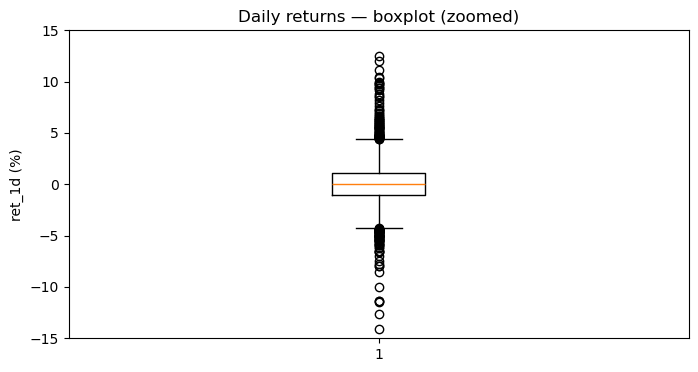

Most extreme daily moves (inspect BEFORE deleting):
      date  ticker  ret_1d
2026-01-27     UNH -19.605
2026-02-05 BTC-USD -14.130
2026-06-04    AVGO -12.587
2026-02-06 BTC-USD  12.525
2025-08-15     UNH  11.978
2025-12-12    AVGO -11.428
2026-01-30    GC=F -11.366
2025-10-30    META -11.335

Rows kept: 3,594 of 3,594

Return correlations (5x5 corner):
ticker   AAPL  AMZN   AVGO  BRK-B  BTC-USD
ticker                                    
AAPL    1.000 0.300  0.160  0.200    0.150
AMZN    0.300 1.000  0.240  0.040    0.290
AVGO    0.160 0.240  1.000 -0.210    0.310
BRK-B   0.200 0.040 -0.210  1.000   -0.070
BTC-USD 0.150 0.290  0.310 -0.070    1.000

Most correlated pair: AVGO & NVDA (r = 0.51)

Behavior by asset class:
             ret_1d  volatility_7d  pct_up_days
asset_class                                    
commodity     0.096          1.575        0.565
crypto       -0.141          2.060        0.477
equity        0.100          1.854        0.518


In [13]:
# ── LAB CELL L3 — EDA: outliers, correlations, group comparisons ──

# OUTLIER WORKFLOW — spot -> visualize -> inspect -> filter with a defensible rule
plt.figure(figsize=(8, 4))
plt.boxplot(df["ret_1d"])
plt.ylim([-15, 15])          # zoom: extreme outliers compress the box to a line (M2 trick)
plt.title("Daily returns — boxplot (zoomed)"); plt.ylabel("ret_1d (%)")
plt.show()

print("Most extreme daily moves (inspect BEFORE deleting):")
print(df.sort_values("ret_1d", key=abs, ascending=False)
        [["date","ticker","ret_1d"]].head(8).to_string(index=False))

# Defensible rule, stated in words: a >30% single-day move in these large-cap assets
# is almost certainly a data glitch (splits, bad ticks), not a market event.
df_clean = df[df["abs_ret"] < 30].copy()
print(f"\nRows kept: {len(df_clean):,} of {len(df):,}")

# CORRELATION — pivot long->wide so each column is one ticker's return series
returns_wide = df_clean.pivot_table(index="date", columns="ticker", values="ret_1d")
corr = returns_wide.corr()
print("\nReturn correlations (5x5 corner):")
print(corr.iloc[:5, :5].round(2))

pair = corr.where(~np.eye(len(corr), dtype=bool)).abs().stack().idxmax()
print(f"\nMost correlated pair: {pair[0]} & {pair[1]} "
      f"(r = {corr.loc[pair]:.2f})")
# M1 reminder: correlation is not causation — both likely load on a common factor
# (the market), a textbook CONFOUNDER, not mutual influence.

# GROUP COMPARISON — the groupby workhorse
print("\nBehavior by asset class:")
print(df_clean.groupby("asset_class")[["ret_1d","volatility_7d","up_day"]]
      .mean().round(3).rename(columns={"up_day": "pct_up_days"}))


## 📘 Module 3 Checkpoint — SQL & Databases

> **Databases STORE data · SQL GETS data · Python ANALYZES data.**

Shared spreadsheets break under concurrency, versioning, and redundancy; **relational databases** fix that with structured 2-D tables, related through key columns, **normalized** to store each fact once. The **data-model tradeoff dial** (memorize): **One Big Table** = fastest queries, most storage → **Star schema** = the balance → **Snowflake** = least storage, slowest queries (more joins = less storage = slower).

L4 builds a miniature **star schema**: a `daily_prices` fact table + an `assets` dimension table, joined on `ticker`. It also demonstrates: schema-first exploration via `sqlite_master` (get the schema as text → **paste it into an LLM and it can write your queries** — the post-2022 trick), `LEFT JOIN`, `WHERE`-before-anything (the 23-minute-query lesson: the identical `GROUP BY` that's instant on local SQLite took 23 minutes on a remote MySQL server — **always filter before pulling**), `GROUP BY` + `ORDER BY`, and the fact that **only the connection changes across RDBMS's** — swap `sqlite3.connect` for a SQLAlchemy MySQL engine and the SQL below runs unmodified.


In [14]:
# ── LAB CELL L4 — STORE in SQLite, GET with SQL, ANALYZE in pandas ──
import sqlite3 as sql

# Star-schema-lite: one FACT table + one DIMENSION table (normalized: asset_class
# is stored once per ticker, not repeated on every one of ~3,700 daily rows).
asset_dim = df_clean[["ticker","asset_class"]].drop_duplicates().reset_index(drop=True)

with sql.connect("dashboard_lab.db") as con:
    df_clean[["date","ticker","price","volume","ret_1d","volatility_7d","up_day"]]\
        .to_sql("daily_prices", con, index=False, if_exists="replace")
    asset_dim.to_sql("assets", con, index=False, if_exists="replace")

    # Schema FIRST (and: paste this text into an LLM -> it writes your queries)
    schema = pd.read_sql('SELECT name, sql FROM sqlite_master WHERE type="table"', con)
    print("Tables in the database:"); print(schema["name"].tolist())

    # JOIN + WHERE + GROUP BY + ORDER BY — filter on the server, analyze the small result
    query = """
        SELECT a.asset_class,
               COUNT(*)             AS n_days,
               AVG(p.ret_1d)        AS avg_ret,
               AVG(p.volatility_7d) AS avg_vol,
               AVG(p.up_day)        AS pct_up
        FROM daily_prices AS p
        LEFT JOIN assets  AS a ON p.ticker = a.ticker
        WHERE p.volatility_7d IS NOT NULL          -- filter BEFORE pulling
        GROUP BY a.asset_class
        ORDER BY avg_vol DESC;
    """
    summary = pd.read_sql(query, con)

print("\nSQL result (already aggregated server-side):")
print(summary.round(3))
# Same division of labor at scale: SQLite stored it, SQL fetched exactly the
# aggregate needed, pandas takes it from here.


Tables in the database:
['daily_prices', 'assets']

SQL result (already aggregated server-side):
  asset_class  n_days  avg_ret  avg_vol  pct_up
0      crypto     346   -0.141    2.060   0.477
1      equity    3016    0.100    1.854   0.518
2   commodity     232    0.096    1.575   0.565


## 📘 Module 5 Checkpoint — The Machine-Learning Workflow

**Why EDA isn't enough** (three reasons): too many rows/columns to disentangle by eye · can't establish causation · can't quickly make predictions for *new* cases. So: models.

**The fork that organizes everything downstream** — *Statistics* asks "to what extent does X influence Y, **controlling for** Z?" (understanding relationships). *ML* asks "how well can we **predict** Y from X and Z?" Same math, different question — and different toolchains (statsmodels vs sklearn, coming in L5–L6).

**The manufacturing metaphor:** data = raw materials · **algorithms = tools** · **hyperparameters = settings** (`max_depth`, `k`, `eps`) · **model = the finished product** · goal = actionable insight. The *algorithm* is the procedure; the *model* is what running it on your data produces.

**Supervised vs unsupervised, one-line test:** do you have a known outcome (y)? L5–L7 do (supervised: `next_abs_ret` is continuous → regression; `up_next` is categorical → classification). L8 doesn't (unsupervised → clustering).

**The 5-step skeleton** (used three times below — the whole point is that it transfers):
1. Choose an algorithm (by outcome type)
2. Preprocess: split **columns** (X vs y) → split **rows** (`train_test_split`, 80/20, with a fixed **`random_state`** so results reproduce) → **encode/scale**
3. Fit on **training** data → the model
4. Evaluate on **test** data (`.score()` = R² for regressors, accuracy for classifiers) — the held-out test set is the operational answer to Module 1's survivorship bias: check yourself on data you didn't train on
5. Predict on new data

**Encoding (favorite quiz distinction):** *one-hot* = one column per category; ***dummy* = one less** (a reference category dropped — `get_dummies(drop_first=True)` / `OneHotEncoder(drop="first")`). Regressions need the drop (perfect multicollinearity otherwise); trees don't care. And always **fit encoders/scalers on training data only**, then transform both sets.

**Model selection in one breath** *(the M5 lookup grids, condensed)*: interpretability → linear/logistic regression · raw accuracy → random forests, gradient boosting, neural nets · low compute → naïve Bayes, trees · big data → scalable variants (MiniBatch K-Means, incremental PCA). Time your fits (`%%time`) — with big data, "best" includes runtime.


## 📘 Module 6 Checkpoint — Regression (continuous y)

**The target:** `next_abs_ret` — the *size* of tomorrow's move. (Predicting the signed return would be trying to beat the market; predicting its *magnitude* exploits a real, well-documented phenomenon: **volatility clustering** — turbulent days follow turbulent days.)

**The three dials of regression output** (L5, via statsmodels):
- **Coefficient** → the effect: a 1-point rise in today's `abs_ret` moves tomorrow's expected `abs_ret` by β, *holding other X's constant*
- **p-value** → is that effect distinguishable from noise? **Never interpret a coefficient without it**
- **R² / adjusted R²** → how much of the outcome the model explains. *A significant coefficient ≠ a good predictive model* — in class, `accommodates` was hugely significant for AirBnB price yet explained **0.6%** of the variance. Expect small R² here too; markets are noisy, and saying so honestly *is* the analysis

**Watch the coefficient move between the simple and multiple models** — when adding controls changes β, that's Module 1's **confounding** rendered as arithmetic (in class: accommodates fell from \$104 to \$88 when bedrooms/neighborhood entered). And note the **reference category**: with `drop_first=True`, `asset_class` = *commodity* (alphabetically first) is absorbed into the intercept — every class coefficient reads *relative to commodity*.

**Two toolchains, two jobs** — L5 = **statsmodels** (`smf.ols(...).fit().summary2()` — full inference tables; no row split needed when the goal is explaining). L6 = **sklearn** (`.fit()/.predict()/.score()` on a held-out test set — prediction). Plus a **decision-tree regressor**: splits chosen to minimize average MSE; a prediction = the **mean of the leaf** you land in; **overfits without a stopping rule** (class demo: even `max_depth=5` overfit; we use 3); interpret via `feature_importances_`, not coefficients.


In [15]:
# ── LAB CELL L5 — REGRESSION FOR INFERENCE (statsmodels: coefficients, p-values, R²) ──
import statsmodels.formula.api as smf

model_df = df_clean.copy()

# SIMPLE regression: tomorrow's move size ~ today's move size (volatility clustering)
simple = smf.ols("next_abs_ret ~ abs_ret", data=model_df).fit()

# MULTIPLE regression: add controls (volume surprise + asset class dummies)
multiple = smf.ols("next_abs_ret ~ abs_ret + vol_ratio + C(asset_class)",
                   data=model_df).fit()

print("═" * 30, "SIMPLE MODEL", "═" * 30)
print(simple.summary2().tables[1].round(4))
print(f"R² = {simple.rsquared:.4f}")

print("\n" + "═" * 29, "MULTIPLE MODEL", "═" * 29)
print(multiple.summary2().tables[1].round(4))
print(f"R² = {multiple.rsquared:.4f} | adjusted R² = {multiple.rsquared_adj:.4f}")

print(f"""
READ THE THREE DIALS:
 1. abs_ret coefficient: {simple.params['abs_ret']:+.4f} (simple) -> {multiple.params['abs_ret']:+.4f} (multiple)
    The shift when controls enter = CONFOUNDING made visible (M1 -> M6).
 2. p-value on abs_ret: {multiple.pvalues['abs_ret']:.4g} — {'significant' if multiple.pvalues['abs_ret'] < .05 else 'NOT significant'}.
    Never interpret a coefficient without this number.
 3. R²: small — a real, significant effect that explains only a sliver of the outcome
    (the AirBnB 0.6% lesson). Significant ≠ predictive.
 4. Reference category: C(asset_class) dummies read RELATIVE to 'commodity'
    (alphabetically first, absorbed into the intercept).""")


══════════════════════════════ SIMPLE MODEL ══════════════════════════════
           Coef.  Std.Err.      t  P>|t|  [0.025  0.975]
Intercept  1.262     0.035 36.586  0.000   1.195   1.330
abs_ret    0.149     0.016  9.131  0.000   0.117   0.182
R² = 0.0227

═════════════════════════════ MULTIPLE MODEL ═════════════════════════════
                          Coef.  Std.Err.      t  P>|t|  [0.025  0.975]
Intercept                 1.042     0.102 10.220  0.000   0.842   1.242
C(asset_class)[T.crypto]  0.314     0.124  2.521  0.012   0.070   0.558
C(asset_class)[T.equity]  0.169     0.100  1.687  0.092  -0.027   0.364
abs_ret                   0.138     0.017  8.036  0.000   0.104   0.171
vol_ratio                 0.066     0.034  1.937  0.053  -0.001   0.134
R² = 0.0254 | adjusted R² = 0.0243

READ THE THREE DIALS:
 1. abs_ret coefficient: +0.1495 (simple) -> +0.1378 (multiple)
    The shift when controls enter = CONFOUNDING made visible (M1 -> M6).
 2. p-value on abs_ret: 1.251e-15 — sig

In [16]:
# ── LAB CELL L6 — REGRESSION FOR PREDICTION (sklearn: the 5-step skeleton) ──
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Step 2a — split COLUMNS
x_vars = ["abs_ret", "vol_ratio", "volatility_7d", "asset_class"]
X = pd.get_dummies(model_df[x_vars], columns=["asset_class"],
                   drop_first=True, dtype=int)          # DUMMY encoding for regression
y = model_df["next_abs_ret"]

# Step 2b — split ROWS (reproducible via random_state)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

# Steps 3–4 — fit on TRAIN, evaluate on TEST (never the other way around)
lrm = LinearRegression().fit(x_train, y_train)
dtr = DecisionTreeRegressor(max_depth=3, random_state=42).fit(x_train, y_train)
#     max_depth=3: the stopping rule — unpruned trees memorize the training data

print(f"Linear regression  test R²: {lrm.score(x_test, y_test)*100:5.2f}%")
print(f"Decision tree      test R²: {dtr.score(x_test, y_test)*100:5.2f}%")

# Tree interpretation: no coefficients — feature importances instead
importances = (pd.DataFrame({"Feature": X.columns,
                             "Importance": dtr.feature_importances_})
                 .sort_values("Importance", ascending=False))
print("\nTree feature importances:")
print(importances.round(3).to_string(index=False))

# Step 5 — predict a new case: a calm mega-cap day vs a wild crypto day
new_days = pd.DataFrame([
    {"abs_ret": 0.3, "vol_ratio": 0.9, "volatility_7d": 0.8,
     "asset_class_crypto": 0, "asset_class_equity": 1},
    {"abs_ret": 6.0, "vol_ratio": 2.5, "volatility_7d": 4.5,
     "asset_class_crypto": 1, "asset_class_equity": 0},
])[X.columns]          # column order must MATCH training exactly
preds = lrm.predict(new_days)
print(f"\nPredicted size of tomorrow's move — calm equity day: {preds[0]:.2f}% | wild crypto day: {preds[1]:.2f}%")


Linear regression  test R²:  3.10%
Decision tree      test R²:  2.83%

Tree feature importances:
           Feature  Importance
     volatility_7d       0.452
         vol_ratio       0.282
           abs_ret       0.265
asset_class_crypto       0.000
asset_class_equity       0.000

Predicted size of tomorrow's move — calm equity day: 1.15% | wild crypto day: 2.59%


## 📘 Module 7 Checkpoint — Classification (categorical y)

New target: `up_next` — will tomorrow be an up day? (1/0.) Three algorithms, three mental models *(the Hamster-toy trio)*:
- **Logistic regression** — fits a **sigmoid** (bounded 0–1); produces coefficients + p-values → the only one of the three that gives **inference**. Read the *sign* (+ raises the odds of class 1) and the p-value. `class_weight='balanced'` stops it from winning by always guessing the majority class.
- **Decision tree** — repeatedly splits on the feature that **lowers entropy / maximizes information gain**; human-readable rules; pruned via `ccp_alpha`.
- **KNN** — **lazy: builds no model.** Plots training points, drops the new point in, majority-votes its **k nearest** by Euclidean distance. Hence two quirks: **StandardScaler is mandatory** (unscaled, a 0–2000-range feature swamps a 0–1 one — distance must mean similarity, not units) and **k ≈ √n** (the class rule of thumb: 10,000 rows → k = 100).

**The confusion matrix — the module's core.** FP = Type I error, FN = Type II. Five metrics *(hook: Sensitivity & Specificity read the ROWS — reality; Precision & NPV read the COLUMNS — predictions)*:
| Metric | Formula | Plain English |
|---|---|---|
| Accuracy | (TP+TN)/all | right overall |
| Sensitivity (recall) | TP/(TP+FN) | of actual positives, how many caught |
| Specificity | TN/(TN+FP) | of actual negatives, how many caught |
| Precision | TP/(TP+FP) | when it says positive, how often right |
| NPV | TN/(TN+FN) | when it says negative, how often right |

`cm.ravel()` unpacks **tn, fp, fn, tp** — in that order.

**Expectation-setting:** next-day market *direction* is close to a coin flip; accuracies near 50–55% are honest, not failure. Watch for the **degenerate classifier** — a model that just predicts "up" every day scores ≈ the base rate on accuracy while its specificity collapses to 0. Only the *five-metric view* exposes it: Module 1's "hooked on the wrong metric," caught red-handed. And the closing question — *which model do you take to management?* — is really *which error is expensive*: missing rallies (FN → prioritize sensitivity) or buying into down days (FP → precision).


In [17]:
# ── LAB CELL L7 — CLASSIFICATION: logit vs tree vs KNN + the confusion matrix ──
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score)

clf_df = model_df.copy()
clf_df["up_next"] = np.where(clf_df["next_ret_1d"] > 0, 1, 0)   # the categorical target

# Skeleton steps 2a–2c
xc_vars = ["abs_ret", "vol_ratio", "volatility_7d", "up_day", "asset_class"]
Xc = pd.get_dummies(clf_df[xc_vars], columns=["asset_class"],
                    drop_first=True, dtype=int)                  # drop_first for the logit
yc = clf_df["up_next"]
xc_tr, xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=.2, random_state=42)

# ── INFERENCE: statsmodels Logit — coefficients with p-values ──
logit_sm = sm.Logit(yc_tr, sm.add_constant(xc_tr.astype(float))).fit(disp=0)
print("Logit inference (sign + p-value are what you read):")
print(logit_sm.summary2().tables[1][["Coef.", "P>|z|"]].round(4))

# ── PREDICTION: the three classifiers ──
lr  = LogisticRegression(class_weight="balanced", max_iter=1000).fit(xc_tr, yc_tr)
dtc = DecisionTreeClassifier(class_weight="balanced", ccp_alpha=.004,
                             random_state=42).fit(xc_tr, yc_tr)

scaler = StandardScaler().fit(xc_tr)             # fit on TRAINING only (KNN needs scaling)
k = int(np.sqrt(len(xc_tr)))                     # the square-root rule of thumb
knn = KNeighborsClassifier(n_neighbors=k).fit(scaler.transform(xc_tr), yc_tr)
print(f"\nKNN using k = sqrt({len(xc_tr)}) ≈ {k}")

# ── EVALUATION: full five-metric confusion-matrix readout ──
def five_metrics(y_true, preds):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()     # order: tn, fp, fn, tp!
    return {"Accuracy":    accuracy_score(y_true, preds),
            "Sensitivity": recall_score(y_true, preds, zero_division=0),
            "Specificity": recall_score(y_true, preds, pos_label=0, zero_division=0),
            "Precision":   precision_score(y_true, preds, zero_division=0),
            "NPV":         precision_score(y_true, preds, pos_label=0, zero_division=0)}

results = pd.DataFrame({
    "Logit": five_metrics(yc_te, lr.predict(xc_te)),
    "Tree":  five_metrics(yc_te, dtc.predict(xc_te)),
    "KNN":   five_metrics(yc_te, knn.predict(scaler.transform(xc_te)))}).round(3)
print("\nModel comparison — all five metrics, not just accuracy:")
print(results)

base_rate = yc_te.mean()
print(f"""
HOW TO READ THIS (before taking any model to management):
 • Base rate of up-days in the test set: {base_rate:.1%}. A model whose accuracy
   merely matches this while specificity ≈ 0 is a DEGENERATE classifier —
   it just says "up" every day. Accuracy alone would hide that; the
   five-metric view exposes it (M1: the wrong-metric trap).
 • Near-coin-flip accuracy on next-day direction is the honest result —
   markets are hard. The graded skill is matching the METRIC to the costly
   error: missing rallies (FN) -> sensitivity; buying into down days (FP) -> precision.
 • Want drivers instead of predictions? That's the logit summary above:
   sign + p-value per feature (inference), which trees give only coarsely
   and KNN not at all.""")


Logit inference (sign + p-value are what you read):
                    Coef.  P>|z|
const               0.257  0.131
abs_ret             0.048  0.107
vol_ratio           0.096  0.155
volatility_7d      -0.096  0.023
up_day              0.077  0.305
asset_class_crypto -0.396  0.038
asset_class_equity -0.216  0.161

KNN using k = sqrt(2875) ≈ 53

Model comparison — all five metrics, not just accuracy:
             Logit  Tree   KNN
Accuracy     0.523 0.527 0.490
Sensitivity  0.562 1.000 0.580
Specificity  0.479 0.000 0.388
Precision    0.546 0.527 0.514
NPV          0.495 0.000 0.454

HOW TO READ THIS (before taking any model to management):
 • Base rate of up-days in the test set: 52.7%. A model whose accuracy
   merely matches this while specificity ≈ 0 is a DEGENERATE classifier —
   it just says "up" every day. Accuracy alone would hide that; the
   five-metric view exposes it (M1: the wrong-metric trap).
 • Near-coin-flip accuracy on next-day direction is the honest result —
   mar

## 📘 Module 8 Checkpoint — Clustering (no y at all)

Training wheels off: **no labels, no model, no accuracy score.** Clustering groups similar points to discover structure you didn't know to ask about, and is evaluated by **utility, domain knowledge, and theory** — "less rules, more fun." The non-negotiable principle *(the picnic principle)*: **the algorithm creates the groups; the humans name them afterward** — you don't tell it "find calm vs turbulent days," you look at what it found and *then* christen the regimes. (Exactly the Field Data Project's Bitcoin approach, now on 15 assets.)

**K-Means:** analyst picks **K**; membership = nearest centroid (Euclidean); **every point gets a cluster, always** — outliers get forced in and can drag centroids. **DBSCAN:** analyst picks **eps** (radius) + **min_samples**; a **core point** has ≥ min_samples neighbors within eps, **border points** sit within eps of a core, everything else is **noise, labeled −1** — DBSCAN is allowed to say *this point belongs nowhere*, finds K by itself, and handles weird shapes. Rules of thumb: min_samples ≈ dimensions + 1; if you get one giant cluster + noise, your parameters are too strict (the in-class lesson) — that's a parameter problem, not a data fact.

**The workflow below:** drop ID-like columns (clustering on a ticker symbol is meaningless) → **StandardScaler (mandatory** — distance-based, same reason as KNN) → pick K by **elbow** (inertia/WSS vs k; find where the drop flattens) *and* **silhouette** (−1…1 per point; maximize the average — and expect ~0.2–0.4 on real data; mushy clusters are normal, say so honestly) → fit → **sanity-check cluster sizes** → interpret the **scaled cluster means by sign and relative size** (attach labels to the *original* frame for real-unit statements) → name the clusters → **PCA to 2 components purely to visualize** the high-dimensional result.


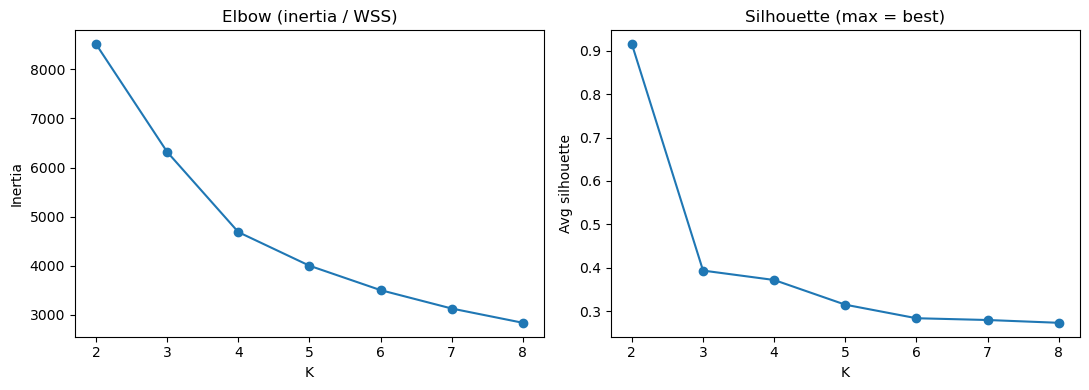

Silhouette peaks at k = 2 (score 0.91). Real-world scores of ~0.2–0.4 mean soft, overlapping groups — normal; say so honestly.

Cluster sizes (sanity check):
cluster
0    3589
1       5

Cluster means — SCALED (read sign & relative size):
         ret_1d  volatility_7d  vol_ratio
cluster                                  
0        -0.000          0.000     -0.030
1         0.730         -0.380     21.280

Cluster means — ORIGINAL units (for real-world statements):
         ret_1d  volatility_7d  vol_ratio
cluster                                  
0         0.070          1.860      0.970
1         1.610          1.470     16.890

Which assets live where (composition, for naming):
col_0           0  1
asset_class         
commodity     227  5
crypto        346  0
equity       3016  0

DBSCAN (eps=1.0, min_samples=4) label counts (−1 = NOISE):
-1      33
 0    3551
 1      10
If this shows one giant cluster + noise, parameters are too strict —
tune eps/min_samples (the in-class lesson: pa

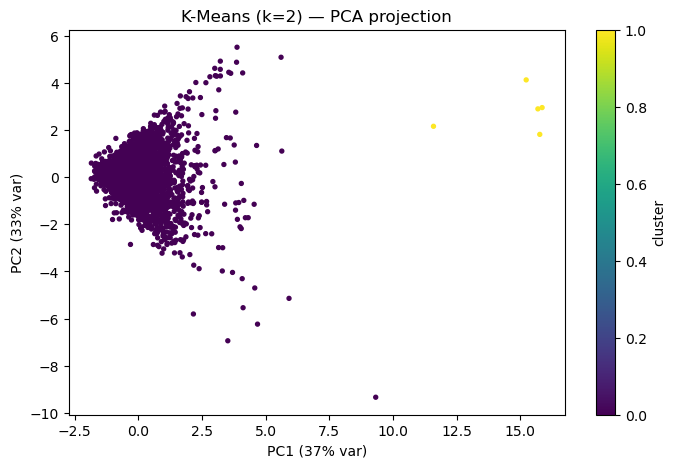

In [18]:
# ── LAB CELL L8 — CLUSTERING: market regimes via K-Means + DBSCAN ──
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Features: ticker-days described by behavior only (no IDs — a ticker symbol
# is an ID, and clustering on IDs is meaningless)
clus_features = ["ret_1d", "volatility_7d", "vol_ratio"]
clus_in = df_clean[clus_features].dropna().reset_index(drop=True)
clus_meta = df_clean.loc[clus_in.index, ["date", "ticker", "asset_class"]]

scaled = StandardScaler().fit_transform(clus_in)        # mandatory: distance-based

# ── Pick K: elbow + silhouette side by side ──
wss, sils = [], []
k_range = range(2, 9)
for k in k_range:
    km_tmp = KMeans(n_clusters=k, n_init=10, random_state=42).fit(scaled)
    wss.append(km_tmp.inertia_)
    sils.append(silhouette_score(scaled, km_tmp.labels_))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(k_range, wss, marker="o");  ax[0].set_title("Elbow (inertia / WSS)")
ax[0].set_xlabel("K");                 ax[0].set_ylabel("Inertia")
ax[1].plot(k_range, sils, marker="o"); ax[1].set_title("Silhouette (max = best)")
ax[1].set_xlabel("K");                 ax[1].set_ylabel("Avg silhouette")
plt.tight_layout(); plt.show()

best_k = list(k_range)[int(np.argmax(sils))]
print(f"Silhouette peaks at k = {best_k} (score {max(sils):.2f}). "
      "Real-world scores of ~0.2–0.4 mean soft, overlapping groups — normal; say so honestly.")

# ── Fit K-Means, check sizes, interpret means ──
km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(scaled)
clus_scaled = pd.DataFrame(scaled, columns=clus_features)
clus_scaled["cluster"] = km.labels_
clus_orig = clus_in.copy(); clus_orig["cluster"] = km.labels_    # labels on BOTH frames

print("\nCluster sizes (sanity check):")
print(clus_scaled["cluster"].value_counts().sort_index().to_string())

print("\nCluster means — SCALED (read sign & relative size):")
print(clus_scaled.groupby("cluster").mean().round(2))
print("\nCluster means — ORIGINAL units (for real-world statements):")
print(clus_orig.groupby("cluster").mean().round(2))

print("\nWhich assets live where (composition, for naming):")
print(pd.crosstab(clus_meta["asset_class"], km.labels_))
# NOW name them (humans, after the algorithm): e.g. a low-vol/low-volume group is
# "Quiet drift", a high-ret/high-vol group is "Risk-on surges", a negative-ret/
# high-vol group is "Stress days" — read YOUR means above and christen accordingly.

# ── DBSCAN: density clustering + explicit noise ──
min_samples = scaled.shape[1] + 1        # rule of thumb: dimensions + 1
db_labels = DBSCAN(eps=1.0, min_samples=min_samples).fit_predict(scaled)
db_counts = pd.Series(db_labels).value_counts().sort_index()
print(f"\nDBSCAN (eps=1.0, min_samples={min_samples}) label counts (−1 = NOISE):")
print(db_counts.to_string())
print("If this shows one giant cluster + noise, parameters are too strict —")
print("tune eps/min_samples (the in-class lesson: parameter sensitivity IS the lesson).")
print("K-Means forces every day into a bucket; DBSCAN flags the weird days as −1 —")
print("that difference in outlier treatment is the key contrast to report.")

# ── PCA: squash 3 dims to 2, purely to SEE the clusters ──
pcs = PCA(n_components=2).fit(scaled)
xy = pcs.transform(scaled)
plt.figure(figsize=(8, 5))
plt.scatter(xy[:, 0], xy[:, 1], c=km.labels_, cmap="viridis", s=8)
plt.title(f"K-Means (k={best_k}) — PCA projection")
plt.xlabel(f"PC1 ({pcs.explained_variance_ratio_[0]:.0%} var)")
plt.ylabel(f"PC2 ({pcs.explained_variance_ratio_[1]:.0%} var)")
plt.colorbar(label="cluster"); plt.show()


---
## 📘 Capstone Checkpoint — this notebook *is* a Field Data Project

Mapped against the FDP rubric (12 points):

| Rubric part | Where this notebook satisfies it |
|---|---|
| **1. Dataset (2)** — ≥500 rows, fits the algorithm, from an API or public source | L1 assembles ~3,700 ticker-day rows from the Yahoo API; supervised targets exist for M6/M7, none needed for M8 ✓ |
| **2. Business problem (3)** — explanatory vs predictive; target; predictors; decision value | Stated per section: L5 is *explanatory* (what drives tomorrow's volatility), L6–L7 *predictive* (size & direction of tomorrow's move), L8 *exploratory* (market regimes). Decision value: position sizing on predicted turbulence, regime-aware risk-taking |
| **3. ETL + run the model (3)** — dtypes, missing values, `info()`/`describe()`, split if predictive | L2 (dates as dates, structural-NaN handling with a stated reason, full familiarization toolkit); train/test splits in L6–L7; correctly *no* split in L5 (inference) and L8 (unsupervised) |
| **4. Evaluate (4)** — metrics matched to model type; insights | p-values + R² for the explanatory model (L5), test-set R² for predictive regression (L6), full confusion-matrix panel for classification (L7), cluster discussion + honest silhouette caveat for clustering (L8) |

That last row is the course's deepest grading rule and Module 1's oldest warning in one line: **the correct evaluation depends on the model type — there is no universal score.**

## 🗺️ The whole course, one screen

```
M1  MINDSET        FACT (assemble=80%) · Three Nesses · Moneyball gap analysis ·
                   counterfactuals (confound/mediate/reverse) · survivorship ·
                   2-4-8 confirmation trap · modus ponens/tollens · wrong-metric warning
M2  PYTHON ETL/EDA read → subset → rename → np.where/np.select → info/describe →
                   boxplot outliers (+ylim zoom) → defensible filter → corr → groupby
M3  SQL            store/get/analyze split · OBT–star–snowflake dial · schema first
                   (+LLM trick) · JOIN on keys · FILTER BEFORE PULLING (23-min lesson)
M4  APIs           build URL → request → parse · SDKs · the 6-step loop (sleep,
                   enumerate, status prints, try/except) · keys in .env · docs > memory
M5  ML WORKFLOW    choose → split cols → split rows (random_state) → encode
                   (dummy = one-hot minus reference) → fit on train → score on test →
                   predict · stats(infer) vs ML(predict) · algorithm-selection grids
M6  REGRESSION     y continuous · coefficient + p-value + R² = three dials ·
                   significant ≠ predictive (0.6% lesson) · coefficients shift with
                   controls (=confounding) · reference category · statsmodels vs
                   sklearn · trees: leaf means, overfitting, max_depth, importances
M7  CLASSIFICATION y categorical · sigmoid vs entropy-splits vs lazy KNN (scale!,
                   k=√n) · confusion matrix: 5 metrics, tn-fp-fn-tp ravel order,
                   Type I/II · degenerate classifiers · metric ↔ costly error
M8  CLUSTERING     no labels/model/accuracy · algorithm groups, HUMANS NAME (picnic) ·
                   K-Means (all points assigned) vs DBSCAN (eps, minPts, −1 = noise) ·
                   elbow + silhouette · always scale · drop IDs · PCA to visualize
FDP CAPSTONE       your data (≥500 rows) → business problem (explanatory | predictive)
                   → ETL → model → METRICS MATCHED TO MODEL TYPE → insight → action
```

*The course in one sentence: frame before you assemble, assemble carefully because it's 80% of the work, run everything through one reusable skeleton, match the algorithm to the outcome type and the metric to the business cost — and always translate the numbers into a decision someone can act on.*


---
# 📊 PART 3 — THE 564 LAB (Marketing 564A + Accounting 564B)

Same rules as the 563 Lab: **every module concept from both 564 courses, demonstrated on this
dashboard's own data.** Marketing cells are prefixed **A** (📕), accounting cells **B** (📗).
Everything below assumes the 563 Lab ran first (it uses `df_clean`, and reuses `headlines` /
`fg_score` from Cell 5 when available — with offline fallbacks so each cell still runs standalone).

| Cell | Course · Module | Concepts covered here |
|---|---|---|
| A1 | 564A M1 — Causal | QDAI · 3 estimators & their biases · parallel trends · DiD regression (β₃) |
| A2 | 564A M2 — Predictive | Ridge/Lasso/RF/XGBoost · scaling rule · C vs alpha · class weighting · confusion matrix · **dollar-value ≠ accuracy** |
| A3 | 564A M3 — Text | 3 classes of sentiment methods · VADER compound · signed HF conversion · disagreement analysis |
| A4 | 564A M4 — Segmentation & CLV | K-Means 4-step · elbow + silhouette + actionability · profiling · CLV mechanics · profitability matrix |
| B1 | 564B M1 — Process Mining | event log (case/activity/timestamp) · discovery · conformance · happy path · variants |
| B2 | 564B M2 — Digit Forensics | Benford first-digit law · Missing-4 uniform test · why the two expectations differ |
| B3 | 564B M3 — Automation | the automation spectrum · SQL audit program (WHERE vs HAVING) · regex brittleness · JSON-schema-constrained output |
| B4 | 564B M4 — Governance | data-as-asset · PK/FK as internal controls · exception reports · lineage & metadata · version control |


In [19]:
# ── 564 LAB CELL X0 — DEPENDENCIES ──────────────────────
# Adds the one new package the 564 lab needs (VADER). Everything else
# (pandas/numpy/sklearn/statsmodels/matplotlib/sqlite3) is already here from the 563 Lab.
!pip install vaderSentiment

## 📕 564A Module 1 Checkpoint — Causal Analysis (DiD on a real market shock)

**The question type changes here.** The 563 Lab predicted (*what will happen?*); this cell asks
*what did an event CAUSE?* — which needs a counterfactual, not a forecast.

- **QDAI** frames the analysis: **Q**uestion → **D**ata (and its generating process!) → **A**nalysis → **I**nsights.
- **Three estimators, three biases:** time-series (T post − T pre) is polluted by *time trends*;
  cross-sectional (T post − C post) is polluted by *baseline differences*; **DiD subtracts both out** —
  but only if **parallel trends** holds (untestable directly; we check *pre*-trends as the standard indirect evidence).
- **DiD as regression:** `ret ~ Treated + Post + Treated×Post` — the **interaction coefficient β₃ IS the causal estimate**.
  β₁ = baseline gap, β₂ = common time effect.
- Design below: the sample's biggest market-wide shock day is the "event"; **high-beta assets = treatment**,
  **defensives = control**. It's a quasi-experiment — assignment isn't random, so read the caveats it prints.

In [20]:
# ── 564 LAB CELL A1 — DiD EVENT STUDY: did the shock CAUSE high-beta underperformance? ──
import statsmodels.formula.api as smf

# Q — Question: did the market shock change daily returns MORE for high-beta assets
#     than the market-wide trend alone would imply?
# D — Data: this dashboard's own daily returns. Data-generating process: exchange prices
#     (no self-reporting incentive — contrast with 564B M2, where reported EPS has one).
# A — Analysis: difference-in-differences around the shock date.
# I — Insights: printed at the bottom.

TREAT_SET   = {"NVDA","TSLA","META","AMZN","AVGO","BTC-USD"}   # high-beta "treatment"
CONTROL_SET = {"JPM","XOM","UNH","LLY","BRK-B","GC=F"}         # defensive "control"

# 1) Find the event: the trading day with the largest cross-asset average |return|,
#    with enough room for a 20-day pre window (plus a 10-day pre-trend check) and 15-day post.
mkt = (df_clean.groupby("date")["ret_1d"].mean().abs().rename("avg_abs"))
dates_sorted = sorted(df_clean["date"].unique())
valid = [d for d in mkt.index if dates_sorted.index(d) >= 30
                              and dates_sorted.index(d) <= len(dates_sorted) - 16]
event = mkt.loc[valid].idxmax()
e_ix  = dates_sorted.index(event)
pre_dates  = dates_sorted[e_ix-20 : e_ix]          # 20 trading days before
post_dates = dates_sorted[e_ix   : e_ix+15]        # event day + 14 after
print(f"Event day (largest market-wide move): {pd.Timestamp(event).date()}  "
      f"(avg |ret| = {mkt.loc[event]:.2f}%)")

win = df_clean[df_clean["date"].isin(pre_dates + post_dates)].copy()
win = win[win["ticker"].isin(TREAT_SET | CONTROL_SET)]
win["Treated"] = win["ticker"].isin(TREAT_SET).astype(int)
win["Post"]    = win["date"].isin(post_dates).astype(int)

# 2) The 2x2 of cell means — 90% of any DiD is this table
cells = win.groupby(["Treated","Post"])["ret_1d"].mean().unstack()
cells.index = ["Control","Treatment"]; cells.columns = ["Pre","Post"]
print("\nMean daily return (%) by group x period:"); print(cells.round(3))

T_pre, T_post = cells.loc["Treatment","Pre"], cells.loc["Treatment","Post"]
C_pre, C_post = cells.loc["Control","Pre"],   cells.loc["Control","Post"]

# 3) Three estimators, three stories
ts  = T_post - T_pre            # time-series: contaminated by the market-wide move itself
cs  = T_post - C_post           # cross-sectional: contaminated by the baseline beta gap
did = (T_post - T_pre) - (C_post - C_pre)   # DiD: both removed
print(f"\nTime-series estimate     : {ts:+.3f} pp/day  (bias: absorbs the common time trend)")
print(f"Cross-sectional estimate : {cs:+.3f} pp/day  (bias: absorbs the pre-existing group gap)")
print(f"Difference-in-differences: {did:+.3f} pp/day  <- the causal estimate, IF trends were parallel")

# 4) Parallel-trends check — the standard INDIRECT evidence (never a proof)
h1 = [d for d in pre_dates[:10]]; h2 = [d for d in pre_dates[10:]]
pt = lambda grp, ds: win[(win["Treated"]==grp) & (win["date"].isin(ds))]["ret_1d"].mean()
t_slope = pt(1,h2) - pt(1,h1); c_slope = pt(0,h2) - pt(0,h1)
print(f"\nPre-trend check (2nd half of pre-window minus 1st half):")
print(f"  Treatment pre-trend: {t_slope:+.3f}   Control pre-trend: {c_slope:+.3f}")
print("  Similar values -> parallel trends *plausible*; it can never be tested directly.")

# 5) DiD as a regression — β on the INTERACTION is the estimate (matches step 3 exactly)
ols = smf.ols("ret_1d ~ Treated + Post + Treated:Post", data=win).fit()
print("\nDiD regression coefficients:")
print(ols.params.round(4).to_string())
print(f"  beta0 = control pre baseline | beta1 = baseline gap | beta2 = common time effect")
print(f"  beta3 (Treated:Post) = {ols.params['Treated:Post']:+.4f}  == the DiD estimate above")

# I — Insight, with the honest quasi-experiment caveats:
print("\nCaveats (say these out loud in any DiD): assignment to 'high-beta' is not random")
print("(selection), a market shock hits betas by definition (exclusion restriction is shaky),")
print("and spillovers across assets are guaranteed. This is a MECHANICS demo, not a paper.")

# Stable report aliases (used by the final consolidated-report cell)
causal_event = event
causal_event_intensity = float(mkt.loc[event])
causal_cells = cells.copy()
causal_estimates = pd.Series({
    "Time-series": ts,
    "Cross-sectional": cs,
    "Difference-in-differences": did,
}, name="pp_per_day")
causal_pretrends = pd.Series({
    "Treatment": t_slope,
    "Control": c_slope,
}, name="pretrend_change")
causal_coefficients = ols.params.copy()


Event day (largest market-wide move): 2026-01-31  (avg |ret| = 6.55%)

Mean daily return (%) by group x period:
             Pre   Post
Control   -0.122  0.302
Treatment -0.031 -0.827

Time-series estimate     : -0.796 pp/day  (bias: absorbs the common time trend)
Cross-sectional estimate : -1.129 pp/day  (bias: absorbs the pre-existing group gap)
Difference-in-differences: -1.220 pp/day  <- the causal estimate, IF trends were parallel

Pre-trend check (2nd half of pre-window minus 1st half):
  Treatment pre-trend: +1.264   Control pre-trend: -0.021
  Similar values -> parallel trends *plausible*; it can never be tested directly.

DiD regression coefficients:
Intercept      -0.122
Treated         0.091
Post            0.424
Treated:Post   -1.220
  beta0 = control pre baseline | beta1 = baseline gap | beta2 = common time effect
  beta3 (Treated:Post) = -1.2197  == the DiD estimate above

Caveats (say these out loud in any DiD): assignment to 'high-beta' is not random
(selection), a mark

## 📕 564A Module 2 Checkpoint — Predictive Analysis (the four-model shootout, scored in dollars)

563's L7 compared logit vs tree vs KNN on accuracy. 564A M2 upgrades that in four ways:

1. **Regularization:** Ridge (L2, shrinks toward zero, never *to* zero) vs Lasso (L1, zeroes out weak
   features = automatic feature selection). In sklearn's `LogisticRegression`, **C is the INVERSE penalty**
   (low C = strong regularization); Lasso needs `solver='saga'`.
2. **The scaling rule:** penalty-based models need `StandardScaler`; **tree models (RF/XGBoost) don't** — same
   logic that made K-Means scaling mandatory.
3. **Class imbalance** handled with `class_weight='balanced'` (the course-approved move), judged on **F1**, not accuracy.
4. **Dollar-value evaluation:** a payoff per confusion-matrix cell. The punchline to look for below:
   the best-*accuracy* model and the best-*dollar* model can differ — **accuracy ≠ decision quality** —
   and even the winner only answers "what will happen," not "what would my trade *cause*"
   (**incrementality** is M1's causal territory).

In [21]:
# ── 564 LAB CELL A2 — RIDGE vs LASSO vs RF vs XGBOOST, judged in dollars ──
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# XGBoost if available; otherwise sklearn's gradient boosting (same family) — log which ran.
try:
    from xgboost import XGBClassifier
    Booster, BOOST_NAME = XGBClassifier, "XGBoost"
    boost_kwargs = dict(n_estimators=200, max_depth=4, learning_rate=0.1,
                        random_state=42, eval_metric="logloss")
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    Booster, BOOST_NAME = GradientBoostingClassifier, "GradBoost (xgboost not installed)"
    boost_kwargs = dict(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)

# Features: today's observable state. Target: will TOMORROW close up? (next_ret_1d > 0)
ml = df_clean.copy()
ml["ret_lag1"] = ml.groupby("ticker")["ret_1d"].shift(1)
ml["ret_5d"]   = ml.groupby("ticker")["ret_1d"].rolling(5).sum().reset_index(level=0, drop=True)
ml = ml.dropna(subset=["ret_lag1","ret_5d","volatility_7d","vol_ratio","next_ret_1d"])
FEATS = ["ret_1d","ret_lag1","ret_5d","volatility_7d","vol_ratio"]
X, y = ml[FEATS], (ml["next_ret_1d"] > 0).astype(int)
print(f"Target balance: {y.mean():.1%} up-days "
      f"(near 50/50 here; ShopNow's 23% is where imbalance really bites — weighting still on).")

# TIME-AWARE split: last 20% of dates as test. Shuffling time series leaks the future
# into training — the finance version of the leakage trap.
cut = ml["date"].quantile(0.8)
tr, te = ml["date"] <= cut, ml["date"] > cut
X_tr, X_te, y_tr, y_te = X[tr], X[te], y[tr], y[te]

scaler = StandardScaler().fit(X_tr)                    # fit on TRAIN only
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

models = {  # (model, needs_scaling)
    "Ridge logistic (L2)": (LogisticRegression(penalty="l2", C=1.0, solver="lbfgs",
                            class_weight="balanced", max_iter=1000), True),
    "Lasso logistic (L1)": (LogisticRegression(penalty="l1", C=1.0, solver="saga",
                            class_weight="balanced", max_iter=3000), True),
    "Random Forest":       (RandomForestClassifier(n_estimators=200, max_depth=5,
                            class_weight="balanced", random_state=42), False),
    BOOST_NAME:            (Booster(**boost_kwargs), False),
}

# Dollar-value payoff per prediction (a $10k overnight position, stylized):
# TP +$10 (rode a gain) | FP -$12 (long into a down day) | FN -$3 (missed gain: opportunity cost) | TN $0
V_TP, V_FP, V_FN, V_TN = 10, -12, -3, 0

rows = []
for name, (m, scale_me) in models.items():
    m.fit(X_tr_s if scale_me else X_tr, y_tr)
    pred = m.predict(X_te_s if scale_me else X_te)
    tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
    rows.append({"Model": name,
                 "Accuracy":  accuracy_score(y_te, pred),
                 "Precision": precision_score(y_te, pred, zero_division=0),
                 "Recall":    recall_score(y_te, pred, zero_division=0),
                 "F1":        f1_score(y_te, pred, zero_division=0),
                 "Dollar":    tp*V_TP + fp*V_FP + fn*V_FN + tn*V_TN})
res = pd.DataFrame(rows).set_index("Model")
print("\nScoreboard (test set, time-aware):"); print(res.round(3).to_string())

best_acc, best_usd = res["Accuracy"].idxmax(), res["Dollar"].idxmax()
print(f"\nBest accuracy: {best_acc}   |   Best DOLLARS: {best_usd}")
print("Same model or not, the lesson holds: pick by the payoff matrix, not the accuracy column")
print("(accuracy != decision quality). And note what NONE of this answers: whether TRADING on the")
print("signal would CAUSE profits net of impact — that's incrementality, i.e. Module 1's question.")

# Interpretation handles: Lasso's zeros (feature selection) + tree importances
lasso = models["Lasso logistic (L1)"][0]
zeroed = [f for f, c in zip(FEATS, lasso.coef_[0]) if abs(c) < 1e-9]
print(f"\nLasso zeroed out: {zeroed or 'nothing (all features earn their keep at C=1.0)'}")
rf = models["Random Forest"][0]
print("RF feature importances:",
      dict(zip(FEATS, rf.feature_importances_.round(3))))
print("Reminder: importance = predictive weight, NOT causation.")

# Stable report aliases
predictive_target_balance = float(y.mean())
predictive_scoreboard = res.copy()
predictive_best_accuracy = best_acc
predictive_best_dollars = best_usd
predictive_lasso_zeroed = list(zeroed)
predictive_rf_importance = pd.Series(
    dict(zip(FEATS, rf.feature_importances_)), name="importance"
).sort_values(ascending=False)


Target balance: 52.1% up-days (near 50/50 here; ShopNow's 23% is where imbalance really bites — weighting still on).


\\?\C:\Users\hasan\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
\\?\C:\Users\hasan\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=N


Scoreboard (test set, time-aware):
                                   Accuracy  Precision  Recall    F1  Dollar
Model                                                                       
Ridge logistic (L2)                   0.497      0.475   0.451 0.462   -1046
Lasso logistic (L1)                   0.496      0.473   0.451 0.462   -1058
Random Forest                         0.536      0.516   0.534 0.525    -694
GradBoost (xgboost not installed)     0.486      0.470   0.570 0.516   -1102

Best accuracy: Random Forest   |   Best DOLLARS: Random Forest
Same model or not, the lesson holds: pick by the payoff matrix, not the accuracy column
(accuracy != decision quality). And note what NONE of this answers: whether TRADING on the
signal would CAUSE profits net of impact — that's incrementality, i.e. Module 1's question.

Lasso zeroed out: nothing (all features earn their keep at C=1.0)
RF feature importances: {'ret_1d': np.float64(0.225), 'ret_lag1': np.float64(0.198), 'ret_5d': np.fl

## 📕 564A Module 3 Checkpoint — Content Analysis (sentiment on the dashboard's own headlines)

Cell 5 already fetches headlines but presents them raw; this cell turns them into a **numeric feature** —
the whole point of M3 (*unstructured text → numbers → the M2 machinery*).

- **Three classes of sentiment methods:** dictionary/rule-based (**VADER** — sentiment encoded *explicitly*
  in a curated lexicon, with rules for negation/emphasis) → supervised transformers (**Hugging Face** — learned
  *implicitly* from labels, context-aware) → generative **LLMs** (sentiment *inferred*, returns themes and narratives).
- **VADER compound ∈ [−1, +1]**; missing/empty text scores **0.0 (neutral)** — never dropped.
- **HF signed conversion:** `+score` if POSITIVE else `−score` (kept as a commented, optional block — the model
  download is heavy, exactly why 564B M3's class shipped a precomputed file).
- **Disagreement analysis:** where a naive word-count dictionary and VADER split reveals *why* method class
  matters (negation, "beats…but…" constructions). And per the coffee-chain breakout: check the **source** of your
  text before trusting its average — the data-generating process shapes the insight.

In [22]:
# ── 564 LAB CELL A3 — VADER SENTIMENT INDEX (and a method-class disagreement demo) ──
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()

def vader_compound(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0                       # missing text -> NEUTRAL, never dropped
    return vader.polarity_scores(text)["compound"]

# Use the live headlines from Cell 5 if present; otherwise a built-in sample so the lab runs offline.
if "headlines" in globals() and isinstance(headlines, dict) and any(headlines.values()):
    heads, source_note = headlines, "live (Cell 5 Yahoo fetch)"
else:
    heads = {"AAPL": ["Apple beats estimates but guidance disappoints investors",
                      "Apple's new chip is not a game changer, analysts say"],
             "NVDA": ["Nvidia surges on record data center demand"],
             "JPM":  ["JPMorgan warns of rising credit losses"]}
    source_note = "OFFLINE SAMPLE (re-run Cell 5 for live text)"
print(f"Headline source: {source_note}")

rows = [{"ticker": t, "headline": h, "vader": vader_compound(h)}
        for t, hs in heads.items() for h in hs]
sent = pd.DataFrame(rows)
per_ticker = (sent.groupby("ticker")["vader"].agg(["mean","count"])
                  .rename(columns={"mean":"avg_compound","count":"n"})
                  .sort_values("avg_compound"))
print("\nPer-ticker sentiment (VADER compound, -1..+1):")
print(per_ticker.round(3).to_string())

overall = sent["vader"].mean()
fg_txt = (f" | CNN Fear&Greed: {fg_score} ({fg_rating})"
          if "fg_score" in globals() and fg_score is not None else "")
print(f"\nHeadline sentiment index: {overall:+.3f}{fg_txt}")
print("Two independent sentiment gauges (text vs survey-style index) — when they DISAGREE,")
print("that's a flag worth investigating, not averaging away.")

# ── Disagreement demo: naive dictionary vs VADER (why method class matters) ──
NAIVE_POS = {"beats","surges","record","gain","up","strong","growth","rally"}
NAIVE_NEG = {"warns","losses","disappoints","down","miss","stalls","cuts","fear"}
def naive_score(text):
    w = set(text.lower().replace(",", " ").split())
    return (len(w & NAIVE_POS) - len(w & NAIVE_NEG)) / max(len(w & (NAIVE_POS|NAIVE_NEG)), 1)

sent["naive"] = sent["headline"].apply(naive_score)
sent["gap"]   = (sent["vader"] - sent["naive"]).abs()
print("\nBiggest naive-vs-VADER disagreements (negation & 'beats...but...' break word counts):")
print(sent.nlargest(3, "gap")[["headline","naive","vader"]].to_string(index=False))
print("\nSame failure pattern one rung up: VADER's rules vs a transformer's context (tentative")
print("phrasing like 'thinking of canceling' scores mild in VADER, strongly negative in HF).")

# OPTIONAL Level-up (heavy download; the reason class shipped precomputed HF scores):
# from transformers import pipeline
# hf = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
# def hf_signed(t):
#     r = hf(t[:512])[0]
#     return r["score"] if r["label"] == "POSITIVE" else -r["score"]   # signed conversion!
# sent["hf"] = sent["headline"].apply(hf_signed)

# Stable report aliases (B1 later reuses the name `per_ticker`)
sentiment_source = source_note
sentiment_by_ticker = per_ticker.copy()
headline_sentiment_index = float(overall)
sentiment_disagreements = sent.nlargest(3, "gap")[["headline", "naive", "vader", "gap"]].copy()


Headline source: live (Cell 5 Yahoo fetch)

Per-ticker sentiment (VADER compound, -1..+1):
         avg_compound  n
ticker                  
JPM            -0.344  4
TSLA           -0.131  4
GC=F           -0.100  4
UNH            -0.016  4
AAPL            0.010  4
LLY             0.024  4
XOM             0.068  4
NVDA            0.105  4
AVGO            0.148  4
BTC-USD         0.158  4
MSFT            0.165  4
GOOGL           0.206  4
META            0.242  4
AMZN            0.412  4

Headline sentiment index: +0.068 | CNN Fear&Greed: 40.8 (Fear)
Two independent sentiment gauges (text vs survey-style index) — when they DISAGREE,
that's a flag worth investigating, not averaging away.

Biggest naive-vs-VADER disagreements (negation & 'beats...but...' break word counts):
                                                                                                              headline  naive  vader
                                                            Intel Stock's AI-Fueled Ra

## 📕 564A Module 4 Checkpoint — Segmentation & CLV (segment the ASSETS, then value the segments)

563's L8 clustered *ticker-days* into market regimes. 564A M4's unit of analysis is the **customer** —
here, the **asset**: one behavioral row per ticker (the RFM analog), then K-Means, then a **CLV-style
valuation** of each segment, then the **profitability matrix**.

- **K-Means four-step:** pick k centers → assign to nearest → recompute centers as means → repeat until stable.
  Objective = minimize inertia. **Scaling mandatory** (distance-based).
- **Choosing k = elbow + silhouette + ACTIONABILITY.** Inertia always falls with k, so it can never be minimized;
  with only 15 assets, business sense caps k hard — exactly the "can the team act on 8 segments?" argument.
- **Profile on ORIGINAL units** (a manager can't act on "−0.3 standard deviations"), then *name* the segments.
- **CLV mechanics** on each segment: expected annual gain on a $10k position × 3-year horizon ÷ (1.10)ᵗ —
  the same margin × lifetime × discounting skeleton as the coffee-chain breakout (65% margin / 3 yr / 10%).
- **Profitability matrix:** value × consistency → True Friends / Butterflies / Barnacles / Strangers.
  The thesis transfers: *don't maximize loyalty (holding time) — manage different assets differently.*

\\?\C:\Users\hasan\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
\\?\C:\Users\hasan\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
\\?\C:\Users\hasan\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
\\?\C:\Users\

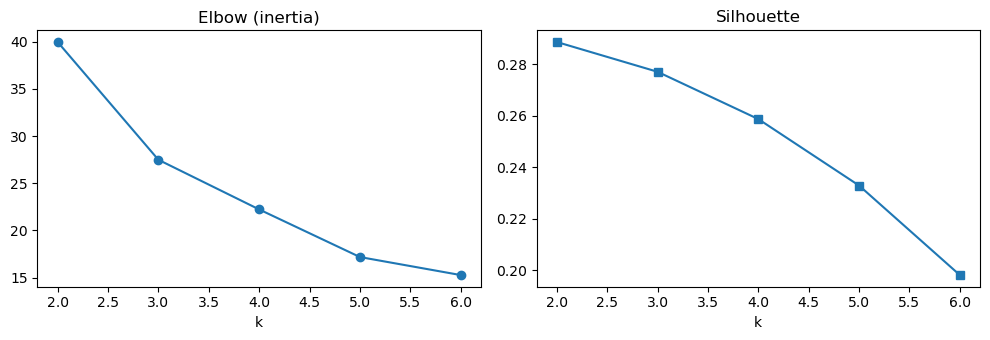

Silhouette favors k=2; choosing k=2 (statistical evidence + business practicality — the M4 two-part argument).

Segment profiles (original units — how you'd brief a PM):
          n  avg_ret   vol  pct_up                                                        members
segment                                                                                          
0         4   -0.069 1.838   0.487                                     BRK-B, BTC-USD, META, MSFT
1        11    0.140 2.099   0.530  AAPL, AMZN, AVGO, GC=F, GOOGL, JPM, LLY, NVDA, TSLA, UNH, XOM

Position Lifetime Value (margin x lifetime x discounting — the CLV skeleton):
         annual_gain       PLV
segment                       
0          -1606.000 -3993.000
1           4223.000 10503.000

Profitability matrix placement:
                                   quadrant
segment                                    
0        Strangers     (minimal allocation)
1          True Friends  (invest & nurture)

The M4 thesis, portfolio 

\\?\C:\Users\hasan\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [23]:
# ── 564 LAB CELL A4 — ASSET SEGMENTATION + "POSITION LIFETIME VALUE" ──
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1) One behavioral row per TICKER (the customer-level view; ticker = ID, so it is
#    carried along but NEVER fed to K-Means)
prof = (df_clean.groupby("ticker")
        .agg(avg_ret=("ret_1d","mean"), vol=("ret_1d","std"),
             pct_up=("up_day","mean"), avg_vol_ratio=("vol_ratio","mean"))
        .reset_index())
SEG_FEATS = ["avg_ret","vol","pct_up","avg_vol_ratio"]

# 2) Scale (distance-based -> mandatory), then elbow + silhouette for k = 2..6
Xs = StandardScaler().fit_transform(prof[SEG_FEATS])
ks = range(2, 7); inert, sils = [], []
for k in ks:
    km_ = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
    inert.append(km_.inertia_); sils.append(silhouette_score(Xs, km_.labels_))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(list(ks), inert, "o-"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), sils, "s-");  ax[1].set_title("Silhouette");      ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()

k_stat = list(ks)[int(np.argmax(sils))]
k_final = min(k_stat, 4)     # ACTIONABILITY: 15 assets can't support many micro-segments
print(f"Silhouette favors k={k_stat}; choosing k={k_final} "
      f"(statistical evidence + business practicality — the M4 two-part argument).")

km = KMeans(n_clusters=k_final, n_init=10, random_state=42).fit(Xs)
prof["segment"] = km.labels_

# 3) Profile on ORIGINAL units and name from the numbers (humans name AFTER the algorithm)
seg = (prof.groupby("segment")
       .agg(n=("ticker","count"), avg_ret=("avg_ret","mean"), vol=("vol","mean"),
            pct_up=("pct_up","mean"),
            members=("ticker", lambda s: ", ".join(s))))
print("\nSegment profiles (original units — how you'd brief a PM):")
print(seg.round(3).to_string())

# 4) CLV mechanics per segment: value each segment like a customer relationship.
#    Annual expected gain on a $10,000 position, 3-year horizon, discounted at 10%.
POSITION, YEARS, DISC = 10_000, 3, 0.10
seg["annual_gain"] = (1 + seg["avg_ret"]/100) ** 252 * POSITION - POSITION   # daily -> annual
seg["PLV"] = sum(seg["annual_gain"] / (1 + DISC) ** t for t in range(1, YEARS + 1))
print("\nPosition Lifetime Value (margin x lifetime x discounting — the CLV skeleton):")
print(seg[["annual_gain","PLV"]].round(0).to_string())

# 5) Profitability matrix: value (PLV) x consistency (pct_up, the 'relationship duration' axis)
hi_v, hi_c = seg["PLV"].median(), seg["pct_up"].median()
def quadrant(r):
    if r["PLV"] >  hi_v and r["pct_up"] >  hi_c: return "True Friends  (invest & nurture)"
    if r["PLV"] >  hi_v:                          return "Butterflies   (harvest, don't over-commit)"
    if r["pct_up"] > hi_c:                        return "Barnacles     (steady but low value: raise or trim)"
    return "Strangers     (minimal allocation)"
seg["quadrant"] = seg.apply(quadrant, axis=1)
print("\nProfitability matrix placement:")
print(seg[["quadrant"]].to_string())
print("\nThe M4 thesis, portfolio edition: the goal isn't to maximize holding time —")
print("it's to manage different assets differently.")

# Stable report aliases
segment_k_statistical = int(k_stat)
segment_k_final = int(k_final)
asset_segment_profiles = seg.copy()


## 📗 564B Module 1 Checkpoint — Process Mining (mine THIS pipeline's own event log)

Process mining reconstructs how work *actually* flows from **log data** (van der Aalst). This dashboard is
itself a process — fetch → validate → feature-build → store — and it leaves **digital footprints**. This cell
builds a real **event log** of the pipeline (minimum three ingredients: **case ID** = ticker run,
**activity**, **timestamp**), then applies all three techniques:

- **Discovery** — recover the paths that actually occurred (the variant table);
- **Conformance** — compare against the intended 4-step model; list deviating cases;
- **Enhancement** — what the deviations say we should fix.

The **happy path** = the *most common* variant (not necessarily the ideal one), and the deviations —
tickers that dropped outlier rows, had thin histories, or failed outright — are where an internal
auditor would look first. Same logic as BW Fishing's uninvoiced orders, one abstraction up.

In [24]:
# ── 564 LAB CELL B1 — EVENT LOG + VARIANT DISCOVERY ON THE DASHBOARD PIPELINE ──
from datetime import timedelta

# 1) Build the event log from what ACTUALLY happened to each ticker in this run.
#    case_id = ticker · activity = pipeline step · timestamp = reconstructed order.
t0 = pd.Timestamp.now().floor("s")
events = []
def log_event(case, act, offset_s):
    events.append({"case_id": case, "activity": act,
                   "timestamp": t0 + timedelta(seconds=offset_s)})

per_ticker = df_clean.groupby("ticker")
full_counts = df.groupby("ticker").size() if "df" in globals() else per_ticker.size()
for i, tick in enumerate(sorted(df_clean["ticker"].unique())):
    base = i * 10
    log_event(tick, "fetch_history",    base + 0)
    log_event(tick, "validate_rows",    base + 1)
    if tick in full_counts and full_counts[tick] > per_ticker.size()[tick]:
        log_event(tick, "drop_outlier_rows", base + 2)      # real: rows lost to the >30% rule
    if per_ticker.size()[tick] < 0.9 * per_ticker.size().max():
        log_event(tick, "flag_thin_history", base + 3)      # real: short/gappy series
    if per_ticker["abs_ret"].max()[tick] > 5:
        log_event(tick, "flag_extreme_move", base + 3.5)    # real: any single move beyond 5%
    log_event(tick, "compute_features", base + 4)
    log_event(tick, "store_sqlite",     base + 5)
for tick in (failed if "failed" in globals() else []):       # Cell L1's failure log
    log_event(tick, "fetch_history", 999); log_event(tick, "fetch_FAILED", 1000)

event_log = pd.DataFrame(events).sort_values(["case_id","timestamp"]).reset_index(drop=True)
print(f"Event log: {len(event_log)} events across {event_log['case_id'].nunique()} cases")
print("(the three mandatory ingredients — case_id, activity, timestamp):")
print(event_log.head(6).to_string(index=False))

# 2) DISCOVERY — reconstruct each case's path, then count variants
paths = (event_log.groupby("case_id")["activity"]
         .apply(lambda a: " → ".join(a)).rename("variant"))
variants = paths.value_counts().rename_axis("variant").reset_index(name="n_cases")
variants["pct"] = (variants["n_cases"] / variants["n_cases"].sum() * 100).round(1)
print("\nVariant table (discovery):")
print(variants.to_string(index=False))

happy = variants.iloc[0]
print(f"\nHappy path = most common variant ({happy['pct']}% of cases; "
      f"{100 - happy['pct']:.1f}% deviate — BWF's was 47%):")
print(f"  {happy['variant']}")

# 3) CONFORMANCE — compare against the intended model
MODEL = "fetch_history → validate_rows → compute_features → store_sqlite"
nonconf = paths[paths != MODEL]
print(f"\nConformance vs intended model: {len(nonconf)} case(s) deviate")
if len(nonconf):
    print(nonconf.to_string())

# 4) ENHANCEMENT — what the deviations tell us to fix
print("\nEnhancement notes: outlier-drops -> add source-side tick validation;")
print("thin histories -> lengthen the fetch range or exclude from rolling stats;")
print("failed fetches -> retry-with-backoff before logging a terminal failure.")

# Stable report aliases
process_event_log = event_log.copy()
process_paths = paths.copy()
process_variants = variants.copy()
process_happy_path = happy.copy()
process_nonconforming = nonconf.copy()


Event log: 87 events across 15 cases
(the three mandatory ingredients — case_id, activity, timestamp):
case_id          activity               timestamp
   AAPL     fetch_history 2026-07-21 10:59:35.000
   AAPL     validate_rows 2026-07-21 10:59:36.000
   AAPL flag_thin_history 2026-07-21 10:59:38.000
   AAPL flag_extreme_move 2026-07-21 10:59:38.500
   AAPL  compute_features 2026-07-21 10:59:39.000
   AAPL      store_sqlite 2026-07-21 10:59:40.000

Variant table (discovery):
                                                                                                variant  n_cases    pct
fetch_history → validate_rows → flag_thin_history → flag_extreme_move → compute_features → store_sqlite       12 80.000
                    fetch_history → validate_rows → flag_thin_history → compute_features → store_sqlite        2 13.300
                    fetch_history → validate_rows → flag_extreme_move → compute_features → store_sqlite        1  6.700

Happy path = most common variant (80.0

## 📗 564B Module 2 Checkpoint — Digit Forensics (Benford on volume, Missing-4 logic on prices)

Two digit tests with two **different** expected distributions — conflating them is the classic error:

- **Benford's first-digit law:** in genuine multi-magnitude data, leading digit d appears with probability
  **log₁₀(1 + 1/d)** — 1 ≈ 30.1%, 2 ≈ 17.6%, decreasing. Trading **volume** spans many orders of magnitude,
  making it ideal Benford material. The five steps: load/clean → extract first digit → count → plot → compare to expected.
- **The Missing-4 test:** the digit **after the decimal point of a value in cents** should be **uniform ≈10% each**.
  For *reported* EPS, managers have a rounding incentive (…4 rounds down, …5 rounds up → too few 4s = quadrophobia,
  Malenko & Grundfest; the digit is extracted as-is, **never rounded**). Market **prices** have no such reporting
  incentive — so this cell doubles as the control group the EPS analysis never had: a distribution with
  *no incentive* should sit flat on the 10% line.

Benford check on 3,591 volume observations:
  Largest deviation: digit 1 (4.4 pp) — roughly Benford-conforming.
  (Deviation = flag for investigation, never a conviction — same rule as the SEC's.)


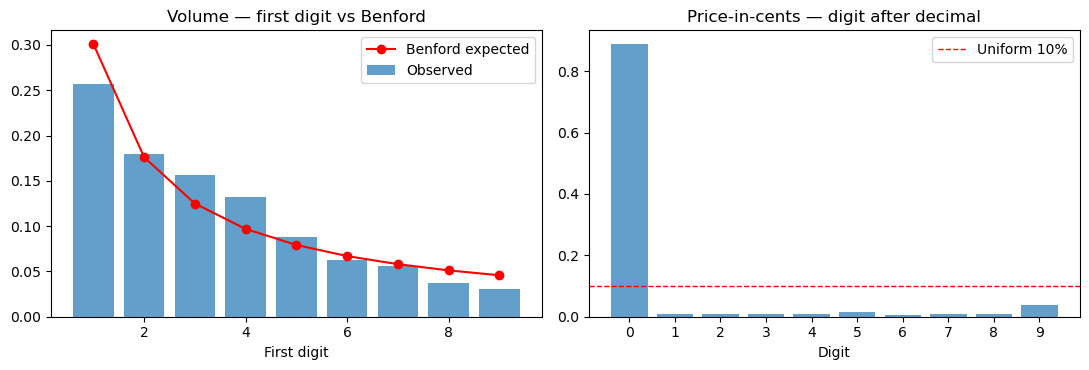


Uniform-digit check: digit 4 = 0.8%, digit 5 = 1.6% (expected ~10% each)
Market prices have no round-up incentive -> flat near 10% is the honest baseline.
Reported EPS pre-2000 ran ~7.4% fours — the gap between THIS chart and that number
is exactly what 'quadrophobia' looks like. Benford = decreasing curve on FIRST digits;
Missing-4 = uniform 10% AFTER the decimal. Two tests, two nulls — never swap them.


In [25]:
# ── 564 LAB CELL B2 — BENFORD (volume) + UNIFORM-DIGIT TEST (prices) ──

# ── Test 1: Benford's law on trading volume ──
vols = df_clean.loc[df_clean["volume"] > 0, "volume"]
first_digit = vols.astype(int).astype(str).str[0].astype(int)
obs = first_digit.value_counts(normalize=True).sort_index()
benford = pd.Series({d: np.log10(1 + 1/d) for d in range(1, 10)})

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(obs.index, obs.values, alpha=0.7, label="Observed")
ax[0].plot(benford.index, benford.values, "ro-", label="Benford expected")
ax[0].set_title("Volume — first digit vs Benford"); ax[0].set_xlabel("First digit"); ax[0].legend()

dev = (obs.reindex(range(1,10), fill_value=0) - benford).abs()
print(f"Benford check on {len(vols):,} volume observations:")
print(f"  Largest deviation: digit {dev.idxmax()} ({dev.max()*100:.1f} pp) — "
      f"{'roughly Benford-conforming' if dev.max() < 0.05 else 'worth a second look'}.")
print("  (Deviation = flag for investigation, never a conviction — same rule as the SEC's.)")

# ── Test 2: Missing-4 logic on prices-in-cents ──
# EPS recipe verbatim: value x 100 -> cents; extract the char AFTER the decimal, NO rounding.
def extract_digit(val):
    s = str(val); i = s.find(".")
    return s[i+1] if (i != -1 and i+1 < len(s)) else "0"

price_cents = (df_clean["price"] * 100).round(6)
digits = price_cents.apply(extract_digit)
freq = digits.value_counts(normalize=True).sort_index()
ax[1].bar(freq.index, freq.values, alpha=0.7)
ax[1].axhline(0.10, color="red", ls="--", lw=1, label="Uniform 10%")
ax[1].set_title("Price-in-cents — digit after decimal"); ax[1].set_xlabel("Digit"); ax[1].legend()
plt.tight_layout(); plt.show()

four = freq.get("4", 0); five = freq.get("5", 0)
print(f"\nUniform-digit check: digit 4 = {four:.1%}, digit 5 = {five:.1%} (expected ~10% each)")
print("Market prices have no round-up incentive -> flat near 10% is the honest baseline.")
print("Reported EPS pre-2000 ran ~7.4% fours — the gap between THIS chart and that number")
print("is exactly what 'quadrophobia' looks like. Benford = decreasing curve on FIRST digits;")
print("Missing-4 = uniform 10% AFTER the decimal. Two tests, two nulls — never swap them.")

# Stable report aliases
benford_observed = obs.copy()
benford_expected = benford.copy()
benford_deviation = dev.copy()
price_digit_frequency = freq.copy()
missing_four_rate = float(four)
missing_five_rate = float(five)


## 📗 564B Module 3 Checkpoint — Automation (place this notebook on the spectrum, then audit with SQL)

**The spectrum:** Level 1 Basic (rules, one app, structured data — *this notebook is a Level 1 artifact:*
a script that fetches, computes, and reports with minimal intervention) → Level 2 RPA (rule-based across
multiple apps) → Level 3 Intelligent (OCR/NLP/LLM on unstructured data) → Level 4 Agents (goal, planning,
tools, adaptation, autonomy). Moving right: rules→independence, one app→many, structured→unstructured.

Three demos below, one per rung that fits offline:

1. **Regex (Level 1)** parsing headline strings — and its brittleness, on display;
2. **The P-Card audit program translated to markets** — the review-threshold list and the *split-transaction*
   pattern (`GROUP BY … HAVING COUNT(*) > 1 AND SUM(...) > threshold`) hunting clustered large moves.
   **WHERE filters rows; HAVING filters groups** — the distinction the whole assignment turned on;
3. **Schema-constrained output (the Level-3 fix):** unconstrained LLM JSON is non-deterministic, so you pin it
   with a schema — demonstrated here with a validator you can run without an API key.

In [26]:
# ── 564 LAB CELL B3 — REGEX, SQL AUDIT PROGRAM, AND A JSON SCHEMA GATE ──
import re, json, sqlite3 as sql

# ── 1) Level-1 rules: regex extraction (and where it cracks) ──
samples = ["NVDA jumps 8.2% on record demand",
           "Bitcoin (BTC-USD) slides 5.1 percent",           # unit written out
           "Gold little changed as yields tick higher"]      # no number at all
pat = re.compile(r"([A-Z]{2,5}(?:-USD)?).*?(-?\d+\.\d)%")
for s in samples:
    m = pat.search(s)
    print(f"  {'HIT ' if m else 'MISS'}  {s}" + (f"   -> {m.groups()}" if m else ""))
print("Rule-based parsing works until the format shifts ('percent', missing numbers) —")
print("the same brittleness the invoice regex showed on a two-line item description.\n")

# ── 2) The P-Card audit program, market edition (SQL on our own store) ──
with sql.connect("dashboard_lab.db") as con:
    # make sure the table exists even if L4 wasn't run this session
    con.execute("SELECT 1").fetchone()
    tables = [r[0] for r in con.execute(
        "SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
    if "daily_prices" not in tables:
        df_clean[["date","ticker","price","volume","ret_1d","volatility_7d","up_day"]]\
            .to_sql("daily_prices", con, index=False, if_exists="replace")

    # (a) Review-threshold list — the '>$3,000 needs three quotes' analog: |move| > 5%
    review = pd.read_sql("""
        SELECT date, ticker, ROUND(ret_1d, 2) AS ret_1d
        FROM daily_prices
        WHERE ABS(ret_1d) > 5              -- WHERE: row-level filter
        ORDER BY ABS(ret_1d) DESC LIMIT 8;""", con)
    print("Review list (single moves beyond the threshold):")
    print(review.to_string(index=False))

    # (b) Split-transaction pattern: SAME ticker, SAME week, MULTIPLE large moves whose
    #     combined size clears a bar — GROUP BY + HAVING, exactly like Denton's P-Cards.
    splits = pd.read_sql("""
        SELECT ticker,
               strftime('%Y-%W', date)      AS week,
               COUNT(*)                     AS n_big_moves,
               ROUND(SUM(ABS(ret_1d)), 1)   AS combined_move
        FROM daily_prices
        WHERE ABS(ret_1d) > 2                       -- rows first (WHERE)...
        GROUP BY ticker, week
        HAVING COUNT(*) > 1 AND SUM(ABS(ret_1d)) > 8  -- ...then groups (HAVING)
        ORDER BY combined_move DESC LIMIT 8;""", con)
    print("\n'Split-style' clusters (repeated large moves, same ticker+week):")
    print(splits.to_string(index=False))
print("\nWHERE filters ROWS before grouping; HAVING filters GROUPS after aggregation.")
print("Each hit is a LEAD for review, not a finding — the P-Card (and Missing-4) discipline.\n")

# ── 3) Level-3 fix: schema-constrained structured output ──
REPORT_SCHEMA = {                       # with a live API you'd pass this as
    "run_date":     str,                # response_format={"type": "json_schema",
    "n_assets":     int,                #   "json_schema": {..., "strict": True}}
    "review_count": int,
    "split_count":  int,
}
def validate(payload, schema):
    missing = [k for k in schema if k not in payload]
    badtype = [k for k in schema if k in payload and not isinstance(payload[k], schema[k])]
    extra   = [k for k in payload if k not in schema]     # additionalProperties: False
    return (not missing and not badtype and not extra), {"missing": missing,
            "wrong_type": badtype, "unexpected": extra}

good = {"run_date": str(pd.Timestamp.now().date()),
        "n_assets": int(df_clean["ticker"].nunique()),
        "review_count": len(review), "split_count": len(splits)}
bad  = {"run_date": 2026, "n_assets": "fifteen", "vibes": "immaculate"}
for name, payload in [("conforming", good), ("non-conforming", bad)]:
    ok, why = validate(payload, REPORT_SCHEMA)
    print(f"{name} payload -> {'ACCEPTED' if ok else 'REJECTED ' + json.dumps(why)}")
print("Unconstrained generative output is non-deterministic; a strict schema makes it")
print("safe to pipe into the next automated step — flexibility AND predictability.")

# Stable report aliases
automation_regex_results = pd.DataFrame([
    {
        "sample": text,
        "matched": bool(pat.search(text)),
        "extracted": str(pat.search(text).groups()) if pat.search(text) else "",
    }
    for text in samples
])
audit_review = review.copy()
audit_splits = splits.copy()
schema_good_ok, schema_good_details = validate(good, REPORT_SCHEMA)
schema_bad_ok, schema_bad_details = validate(bad, REPORT_SCHEMA)
schema_validation_results = pd.DataFrame([
    {"payload": "conforming", "accepted": schema_good_ok, "details": json.dumps(schema_good_details)},
    {"payload": "non-conforming", "accepted": schema_bad_ok, "details": json.dumps(schema_bad_details)},
])


  HIT   NVDA jumps 8.2% on record demand   -> ('NVDA', '8.2')
  MISS  Bitcoin (BTC-USD) slides 5.1 percent
  MISS  Gold little changed as yields tick higher
Rule-based parsing works until the format shifts ('percent', missing numbers) —
the same brittleness the invoice regex showed on a two-line item description.

Review list (single moves beyond the threshold):
               date  ticker  ret_1d
2026-01-27 00:00:00     UNH -19.610
2026-02-05 00:00:00 BTC-USD -14.130
2026-06-04 00:00:00    AVGO -12.590
2026-02-06 00:00:00 BTC-USD  12.520
2025-08-15 00:00:00     UNH  11.980
2025-12-12 00:00:00    AVGO -11.430
2026-01-30 00:00:00    GC=F -11.370
2025-10-30 00:00:00    META -11.330

'Split-style' clusters (repeated large moves, same ticker+week):
 ticker    week  n_big_moves  combined_move
BTC-USD 2026-05            5         36.200
   AVGO 2026-22            4         28.200
    LLY 2026-05            4         25.700
    UNH 2026-04            2         23.600
BTC-USD 2026-22          

## 📗 564B Module 4 Checkpoint — Data Governance (govern this dashboard's data like the asset it is)

**Data is an asset** (FASB: a present right to an economic benefit): this pipeline's data is owned,
generates value, has a lifecycle, decays without maintenance, costs money to keep clean, and must be
safeguarded. The six controls translate directly, and this cell *implements* four of them:

1. **Asset inventory + audit trail** → a lineage/metadata record (source, fetch time, row counts, content hash);
2. **Referential integrity as an internal control** → a governed SQLite store with **PK/FK constraints ON**,
   plus a live demonstration of the schema *rejecting* bad data (a FK violation is a control operating, not an error);
3. **Exception reports** → completeness and orphan checks (`IS NULL`, `LEFT JOIN … WHERE key IS NULL`);
4. **Version control** → the lineage JSON is exactly what you'd commit alongside the data (Git tracks changes;
   GitHub hosts it) — the cure for *fragmented ownership*, one of the seven failure types
   (quality · single-source · lineage · access/privacy · incentives · ownership · oversight — Boeing / Conduent / VW
   being the case studies for #2, #4, #5). And the standing warning: **AI magnifies the need for governance.**

In [27]:
# ── 564 LAB CELL B4 — A GOVERNED DATA STORE (PK/FK controls, exceptions, lineage) ──
import sqlite3 as sql, hashlib, json

DB = "dashboard_governed.db"
with sql.connect(DB) as con:
    con.execute("PRAGMA foreign_keys = ON;")          # enforcement OFF by default in SQLite!
    con.executescript("""
        DROP TABLE IF EXISTS daily_prices;
        DROP TABLE IF EXISTS assets;
        CREATE TABLE assets (                          -- DIMENSION
            ticker       TEXT PRIMARY KEY,             -- PK: unique + non-null
            asset_class  TEXT NOT NULL
        );
        CREATE TABLE daily_prices (                    -- FACT
            date    TEXT NOT NULL,
            ticker  TEXT NOT NULL REFERENCES assets(ticker),   -- FK: referential integrity
            price   REAL, volume REAL, ret_1d REAL,
            PRIMARY KEY (date, ticker)                 -- composite PK: one row per (date,ticker)
        );""")
    dim = df_clean[["ticker","asset_class"]].drop_duplicates()
    dim.to_sql("assets", con, index=False, if_exists="append")
    fact = df_clean[["date","ticker","price","volume","ret_1d"]].copy()
    fact["date"] = fact["date"].astype(str)            # SQLite stores dates as TEXT (YYYY-MM-DD)
    fact.to_sql("daily_prices", con, index=False, if_exists="append")

    # ── The schema IS an internal control: watch it reject an orphan row ──
    try:
        con.execute("INSERT INTO daily_prices VALUES ('2026-07-10','FAKE',1,1,0.0)")
        fk_control_status = "FAILED — orphan row was accepted"
        print("✗ orphan row accepted — FK enforcement is not on!")
    except sql.IntegrityError as e:
        fk_control_status = f"PASSED — orphan insert rejected ({e})"
        print(f"✓ FK control operated as designed — orphan insert REJECTED ({e})")

    # ── Exception reports (detective controls) ──
    completeness = pd.read_sql("""
        SELECT a.ticker, COUNT(p.date) AS n_days
        FROM assets a LEFT JOIN daily_prices p ON a.ticker = p.ticker
        GROUP BY a.ticker ORDER BY n_days ASC LIMIT 5;""", con)
    print("\nCompleteness check (thinnest coverage first):")
    print(completeness.to_string(index=False))

    nulls = pd.read_sql("""
        SELECT COUNT(*) AS null_price_rows
        FROM daily_prices WHERE price IS NULL;""", con)   # IS NULL, never "= NULL"
    print(f"\nNULL scan: {int(nulls['null_price_rows'][0])} rows with missing price")

# ── Lineage & metadata: the audit trail for a data asset ──
content_hash = hashlib.sha256(
    pd.util.hash_pandas_object(df_clean, index=False).values.tobytes()).hexdigest()[:16]
lineage = {
    "dataset":        "dashboard daily prices",
    "sources":        ["query2.finance.yahoo.com (prices/volume)",
                       "api.stlouisfed.org (macro, Part 1)",
                       "CNN Fear & Greed (sentiment, Part 1)"],
    "generated_at":   str(pd.Timestamp.now()),
    "rows":           int(len(df_clean)),
    "tickers":        int(df_clean["ticker"].nunique()),
    "date_range":     [str(df_clean["date"].min().date()), str(df_clean["date"].max().date())],
    "content_sha256": content_hash,       # change the data -> the hash changes -> decay is visible
    "transformations":["dtype coercion","rename close->price","returns/vol features",
                       ">30% outlier rule","dropna on rolling-window edges"],
    "owner":          "Hasan (dashboard maintainer)",   # named owner = no accountability gap
}
with open("dashboard_lineage.json", "w") as f:
    json.dump(lineage, f, indent=2)
print("\nLineage record written -> dashboard_lineage.json")
print(json.dumps(lineage, indent=2)[:400] + " ...")
print("\nCommit this JSON next to the notebook (git) and every run leaves a versioned,")
print("hash-verified audit trail: inventory + lineage + ownership — governance in ~40 lines.")

# Stable report aliases
governance_completeness = completeness.copy()
governance_nulls = nulls.copy()
governance_lineage = dict(lineage)


✓ FK control operated as designed — orphan insert REJECTED (FOREIGN KEY constraint failed)

Completeness check (thinnest coverage first):
ticker  n_days
  AAPL     232
  AMZN     232
  AVGO     232
 BRK-B     232
  GC=F     232

NULL scan: 0 rows with missing price

Lineage record written -> dashboard_lineage.json
{
  "dataset": "dashboard daily prices",
  "sources": [
    "query2.finance.yahoo.com (prices/volume)",
    "api.stlouisfed.org (macro, Part 1)",
    "CNN Fear & Greed (sentiment, Part 1)"
  ],
  "generated_at": "2026-07-21 10:59:35.991228",
  "rows": 3594,
  "tickers": 15,
  "date_range": [
    "2025-08-09",
    "2026-07-20"
  ],
  "content_sha256": "61b5f94f48988e52",
  "transformations": [
     ...

Commit this JSON next to the notebook (git) and every run leaves a versioned,
hash-verified audit trail: inventory + lineage + ownership — governance in ~40 lines.


---
## ✅ 564 Lab wrap — the coverage map

| Course · Module | Concept | Where it lives |
|---|---|---|
| 564A M1 | QDAI · time-series/cross-sectional/DiD + biases · parallel-trends check · DiD regression β₃ | A1 |
| 564A M2 | Ridge/Lasso (C inverse, saga) · RF/XGBoost · scale-for-penalties-not-trees · class weighting · time-aware split · confusion matrix · **dollar value ≠ accuracy** · incrementality caveat | A2 |
| 564A M3 | dictionary → transformer → LLM ladder · VADER compound · neutral-0.0 for missing text · signed HF conversion (stub) · disagreement analysis · source-of-text skepticism | A3 |
| 564A M4 | K-Means 4-step · mandatory scaling · elbow + silhouette + actionability · profile in original units · segment naming · CLV (margin × lifetime × discounting) · profitability matrix | A4 |
| 564B M1 | event log (case/activity/timestamp) · discovery/conformance/enhancement · happy path & variants · deviations as audit leads | B1 |
| 564B M2 | Benford log₁₀(1+1/d) on volume · Missing-4 uniform-10% on prices-in-cents · extract-don't-round · flag-not-conviction | B2 |
| 564B M3 | automation spectrum (this notebook = Level 1) · regex brittleness · review-threshold + split-pattern SQL (WHERE vs **HAVING**) · schema-constrained output | B3 |
| 564B M4 | data-as-asset · PK/FK as internal controls (live rejection) · IS NULL / LEFT-JOIN exception reports · lineage + content hash · named ownership · version control | B4 |

One dataset, eight modules, two courses. The dashboard fetches (563 M4), stores (563 M3 / 564B M4),
predicts (563 M6-7 / 564A M2), clusters (563 M8 / 564A M4), reads text (564A M3), estimates causal
effects (564A M1), audits itself (564B M1-3), and governs its own data (564B M4). **FACT, QDAI, and
the audit mindset — all running against the same fifteen tickers.**

---
# 📈 PART 4 — THE FIN 575 LAB (Investments & Performance Evaluation)

Same rules as the 563/564 Labs: **the course's asset-pricing toolkit, demonstrated on this
dashboard's own 15 assets.** Cells are prefixed **F**. Everything below assumes the 563 Lab ran
first (it uses `df_clean`); F3 also benefits from A3's sentiment output, with a neutral fallback.

This is the layer the notebook was missing: Parts 1–3 *describe, predict, and audit* the data.
Part 4 asks the FIN 575 question — **are the returns themselves explainable, and what would a
risk-adjusted investor do about it?**

| Cell | FIN 575 concept | Where it comes from |
|---|---|---|
| F1 | CAPM & 3-Factor regressions — alpha, beta, R² per asset; **low R² = diversifier** | AQR case Q1 & Q4 |
| F2 | Cross-sectional momentum — winners vs losers; continuation = **under-reaction**, reversal = **over-reaction** | AQR case Q2, Q5 |
| F3 | Public information as a slow-priced signal — headline sentiment wired **into** the forecasting models | Employee-satisfaction case Q8 |
| F4 | Signal committee → per-asset stance, with **turnover/churn** measured (paper alpha ≠ realized alpha) | AQR case Q2, Q8 |
| F5 | Implied perpetual growth backed out of a valuation multiple — the terminal-value smell test | Interco case Q10–Q11 |


## 📈 F1 Checkpoint — Factor regressions: from *describing* prices to *explaining* returns

Parts 1–2 computed RSI and moving averages (time-series descriptions of one asset at a time).
FIN 575's core move is different: regress each asset's **excess return** on common risk factors.

- **Beta** — how much market risk the asset carries (AQR: momentum L/S had β = −0.17).
- **Alpha** — the return *left over* after risk exposure is paid for. Persistent alpha means either
  mispricing or a missing risk factor.
- **R²** — the share of the asset's variability the factors explain. The AQR case's sharpest lesson
  (Q4): the momentum strategy's R² of 0.02–0.07 is what made it a genuine **diversifier**. We apply
  the same read here: any asset with a low R² against the factors is flagged as a diversification
  candidate.

The cell tries the real **Fama-French daily factors** (Ken French library — one more API, Module 4
style); if unreachable it falls back to a SPY market proxy, then to an equal-weight index of the 15
assets, and *labels which source it used* — the report should never hide its data provenance (564B M4).


In [28]:
# ── FIN 575 CELL F1 — CAPM + 3-FACTOR REGRESSIONS PER ASSET ─────────────────
import io, zipfile
import statsmodels.api as sm

# 0) Daily returns in decimal form, wide by ticker (from the Lab's cleaned data)
_rets = (df_clean.pivot_table(index="date", columns="ticker", values="ret_1d")
         .sort_index() / 100.0)

# 1) Factor ladder: Fama-French daily -> SPY proxy -> equal-weight internal proxy
factors, fin575_factor_source = None, None
try:
    _ff_url = ("https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
               "F-F_Research_Data_Factors_daily_CSV.zip")
    _z = zipfile.ZipFile(io.BytesIO(requests.get(_ff_url, timeout=30).content))
    _ff = pd.read_csv(_z.open(_z.namelist()[0]), skiprows=3)
    _ff = _ff.rename(columns={_ff.columns[0]: "date"})
    _ff = _ff[_ff["date"].astype(str).str.strip().str.len() == 8]
    _ff["date"] = pd.to_datetime(_ff["date"].astype(str).str.strip(), format="%Y%m%d")
    for c in ["Mkt-RF", "SMB", "HML", "RF"]:
        _ff[c] = pd.to_numeric(_ff[c], errors="coerce") / 100.0
    factors = _ff.set_index("date")[["Mkt-RF", "SMB", "HML", "RF"]].dropna()
    fin575_factor_source = "Fama-French daily factors (Ken French Data Library)"
except Exception as e:
    print(f"· Fama-French download unavailable ({type(e).__name__}); trying SPY proxy…")
    try:
        _spy = pd.DataFrame(fetch_history("SPY")).set_index("date")["close"]
        _mkt = _spy.pct_change().rename("Mkt-RF").to_frame()
        _mkt["SMB"] = np.nan; _mkt["HML"] = np.nan; _mkt["RF"] = 0.0
        factors = _mkt.dropna(subset=["Mkt-RF"])
        fin575_factor_source = "SPY market proxy (RF≈0; no size/value factors)"
    except Exception as e2:
        print(f"· SPY proxy also unavailable ({type(e2).__name__}); using equal-weight internal proxy.")
        _mkt = _rets.mean(axis=1).rename("Mkt-RF").to_frame()
        _mkt["SMB"] = np.nan; _mkt["HML"] = np.nan; _mkt["RF"] = 0.0
        factors = _mkt
        fin575_factor_source = "equal-weight index of the 15 tracked assets (internal proxy; RF≈0)"
print(f"Factor source: {fin575_factor_source}")

_has_3f = factors["SMB"].notna().any()
_panel = _rets.join(factors, how="inner").dropna(subset=["Mkt-RF"])
print(f"Aligned {len(_panel)} trading days of returns with the factor series.")

# 2) Per-asset regressions: CAPM always; 3-Factor when SMB/HML exist
_rows = []
for t in _rets.columns:
    y = (_panel[t] - _panel["RF"]).dropna()
    if len(y) < 60:            # too little overlap for a meaningful beta
        continue
    Xc = sm.add_constant(_panel.loc[y.index, ["Mkt-RF"]])
    capm = sm.OLS(y, Xc).fit()
    row = {"ticker": t,
           "capm_beta":  capm.params["Mkt-RF"],
           "capm_alpha_ann_pct": capm.params["const"] * 252 * 100,
           "capm_r2":    capm.rsquared}
    if _has_3f:
        X3 = sm.add_constant(_panel.loc[y.index, ["Mkt-RF", "SMB", "HML"]].dropna())
        y3 = y.loc[X3.index]
        f3 = sm.OLS(y3, X3).fit()
        row.update({"mkt_beta_3f": f3.params["Mkt-RF"],
                    "smb_beta": f3.params["SMB"], "hml_beta": f3.params["HML"],
                    "alpha_3f_ann_pct": f3.params["const"] * 252 * 100,
                    "r2_3f": f3.rsquared})
    _rows.append(row)

fin575_factor_table = (pd.DataFrame(_rows).set_index("ticker")
                       .sort_values("capm_alpha_ann_pct", ascending=False))

# 3) The AQR Q4 read: low R² against the factors = diversification candidate
R2_DIVERSIFIER_CUT = 0.30
fin575_factor_table["diversifier"] = np.where(
    fin575_factor_table["capm_r2"] < R2_DIVERSIFIER_CUT, "yes — low factor R²", "")
fin575_low_r2_assets = list(
    fin575_factor_table.index[fin575_factor_table["capm_r2"] < R2_DIVERSIFIER_CUT])

print("\nPer-asset factor regressions (sorted by CAPM alpha, annualized %):")
_show = ["capm_beta", "capm_alpha_ann_pct", "capm_r2"] + (
        ["smb_beta", "hml_beta", "alpha_3f_ann_pct", "r2_3f"] if _has_3f else []) + ["diversifier"]
print(fin575_factor_table[_show].round(3).to_string())
print(f"\nDiversification candidates (CAPM R² < {R2_DIVERSIFIER_CUT}): "
      f"{fin575_low_r2_assets or 'none'}")
print("Reminder (AQR Q3): an alpha that survives risk adjustment is only expected to PERSIST")
print("if it is compensation for a real risk — a historical alpha is evidence, not a promise.")


Factor source: Fama-French daily factors (Ken French Data Library)
Aligned 202 trading days of returns with the factor series.

Per-asset factor regressions (sorted by CAPM alpha, annualized %):
         capm_beta  capm_alpha_ann_pct  capm_r2  smb_beta  hml_beta  alpha_3f_ann_pct  r2_3f          diversifier
ticker                                                                                                           
GOOGL        1.324              56.543    0.315    -0.137    -0.469            65.627  0.343                     
LLY          0.576              52.858    0.042     0.489    -0.219            59.803  0.058  yes — low factor R²
XOM         -0.382              44.232    0.039    -0.151     0.679            29.359  0.120  yes — low factor R²
UNH          0.561              36.819    0.033     0.162     0.098            35.579  0.035  yes — low factor R²
GC=F         0.549              30.007    0.060    -0.025     0.036            29.133  0.060  yes — low factor R²
AAPL   

## 📈 F2 Checkpoint — Cross-sectional momentum: winners vs losers, and what a reversal would mean

RSI is *time-series* momentum on one asset. The AQR case is about **cross-sectional** momentum:
rank the universe by trailing return, go long the top bucket and short the bottom. Two course
ideas get tested at once:

1. **The strategy itself** — form a formation-period return (skipping the most recent month, the
   standard convention that avoids short-term reversal contamination), rank the 15 assets, and
   measure the winner-minus-loser spread over the holding window.
2. **Over- vs under-reaction (AQR Q5)** — if formation-period winners *keep* outperforming, prices
   under-reacted to good news (continuation). If they *reverse*, investors pushed prices too far
   (over-reaction). The rank correlation between formation and holding returns is the diagnostic.

With 15 assets and ~1 year of data this is a demonstration, not the 1927–2014 evidence base —
the sample-size caveat is itself a Module 1 lesson.


In [29]:
# ── FIN 575 CELL F2 — CROSS-SECTIONAL MOMENTUM + OVER/UNDER-REACTION TEST ───
from scipy.stats import spearmanr

_px = df_clean.pivot_table(index="date", columns="ticker", values="price").sort_index()
SKIP, HOLD = 21, 21                       # skip-month convention; ~1-month holding window
LOOKBACK = min(126, max(40, len(_px) - SKIP - HOLD - 5))   # ~6 months if available

_end_hold  = _px.index[-1]
_end_form  = _px.index[-(HOLD + 1)]                 # holding window = last ~month
_start_form = _px.index[-(HOLD + SKIP + LOOKBACK)]
_end_skip   = _px.index[-(HOLD + SKIP)]

form_ret = (_px.loc[_end_skip] / _px.loc[_start_form] - 1) * 100   # formation (skips last month pre-hold)
hold_ret = (_px.loc[_end_hold] / _px.loc[_end_form] - 1) * 100     # subsequent holding return

mom = pd.DataFrame({"formation_ret_pct": form_ret, "holding_ret_pct": hold_ret}).dropna()
mom["rank"] = mom["formation_ret_pct"].rank(ascending=False).astype(int)
_n_bucket = max(3, len(mom) // 3)
mom["bucket"] = "middle"
mom.loc[mom["rank"] <= _n_bucket, "bucket"] = "winner"
mom.loc[mom["rank"] > len(mom) - _n_bucket, "bucket"] = "loser"
mom = mom.sort_values("rank")

wml = (mom.loc[mom["bucket"] == "winner", "holding_ret_pct"].mean()
       - mom.loc[mom["bucket"] == "loser", "holding_ret_pct"].mean())
rho, pval = spearmanr(mom["formation_ret_pct"], mom["holding_ret_pct"])

print(f"Formation window: {pd.Timestamp(_start_form).date()} → {pd.Timestamp(_end_skip).date()} "
      f"({LOOKBACK} trading days, skipping the {SKIP}-day pre-holding month)")
print(f"Holding window:   {pd.Timestamp(_end_form).date()} → {pd.Timestamp(_end_hold).date()}\n")
print(mom.round(2).to_string())
print(f"\nWinner-minus-loser holding-period spread: {wml:+.2f} pct pts")
print(f"Spearman rank corr (formation vs holding): ρ = {rho:+.2f} (p = {pval:.2f})")

if rho > 0.15:
    fin575_momentum_read = ("CONTINUATION — winners kept winning, consistent with UNDER-reaction "
                            "(prices adjust to news gradually)")
elif rho < -0.15:
    fin575_momentum_read = ("REVERSAL — winners gave back gains, consistent with OVER-reaction "
                            "(AQR Q5: the later reversal corrects the overpricing)")
else:
    fin575_momentum_read = ("NO CLEAR PATTERN — with 15 assets and one window, neither hypothesis "
                            "is supported; this is exactly why the case used 88 years of deciles")
print(f"\nRead: {fin575_momentum_read}")
print("Turnover reminder (AQR Q2): momentum ranks re-shuffle monthly — F4 measures how much.")

# Stable report aliases
fin575_momentum_table = mom.copy()
fin575_momentum_spearman = float(rho)
fin575_wml_spread = float(wml)


Formation window: 2026-02-03 → 2026-06-09 (126 trading days, skipping the 21-day pre-holding month)
Holding window:   2026-06-29 → 2026-07-20

         formation_ret_pct  holding_ret_pct  rank  bucket
ticker                                                   
UNH                 45.330            0.410     1  winner
AVGO                22.420            1.530     2  winner
NVDA                15.440            4.260     3  winner
LLY                 14.070           -6.750     4  winner
AAPL                 7.820           15.920     5  winner
GOOGL                7.230           -0.470     6  middle
XOM                  3.600            9.040     7  middle
AMZN                 2.330            4.100     8  middle
JPM                 -0.680            2.880     9  middle
BRK-B               -1.210           -0.960    10  middle
MSFT                -1.900            9.150    11   loser
TSLA                -5.990          -10.260    12   loser
GC=F               -13.130           -0.300  

## 📈 F3 Checkpoint — Sentiment as a *priced* signal: wiring the text pipeline into the models

The employee-satisfaction case's whole thesis is that **public, text-based information can predict
returns because the market is slow to incorporate it**. A3 built the sentiment gauge; A2 built the
forecasting shootout — but they never touched. This cell connects them: the per-ticker VADER
compound score becomes a **feature** in the same time-aware Ridge/Lasso/RF comparison, scored on
the same dollar-payoff rule.

Method notes carried over: missing text → neutral 0.0, never dropped (A3 rule); scale for the
penalized models, not the trees (A2 rule); fit the scaler on train only. The honest comparison is
**with-vs-without on identical splits** — if sentiment adds nothing here, that is a finding about
this sample (one snapshot of headlines has almost no cross-time variation), not a verdict on the
strategy class.


In [30]:
# ── FIN 575 CELL F3 — ADD SENTIMENT AS A MODEL INPUT (with vs without) ──────
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1) Per-ticker sentiment feature from A3 (neutral 0.0 fallback keeps the cell standalone)
if "sentiment_by_ticker" in globals() and sentiment_by_ticker is not None:
    _sent_map = sentiment_by_ticker["avg_compound"].to_dict()
    fin575_sentiment_feature_used = f"VADER avg compound per ticker ({sentiment_source})"
else:
    _sent_map = {}
    fin575_sentiment_feature_used = "no headlines available — all tickers neutral 0.0"
print(f"Sentiment feature: {fin575_sentiment_feature_used}")

# 2) Rebuild the A2 feature set on identical rows, add sent_score
_ml = df_clean.copy()
_ml["ret_lag1"] = _ml.groupby("ticker")["ret_1d"].shift(1)
_ml["ret_5d"]   = _ml.groupby("ticker")["ret_1d"].rolling(5).sum().reset_index(level=0, drop=True)
_ml["sent_score"] = _ml["ticker"].map(_sent_map).fillna(0.0)
_ml = _ml.dropna(subset=["ret_lag1", "ret_5d", "volatility_7d", "vol_ratio", "next_ret_1d"])

BASE_FEATS = ["ret_1d", "ret_lag1", "ret_5d", "volatility_7d", "vol_ratio"]
SENT_FEATS = BASE_FEATS + ["sent_score"]
_y = (_ml["next_ret_1d"] > 0).astype(int)
_cut = _ml["date"].quantile(0.8)                 # same time-aware split rule as A2
_tr, _te = _ml["date"] <= _cut, _ml["date"] > _cut

V_TP, V_FP, V_FN, V_TN = 10, -12, -3, 0          # same stylized payoff matrix as A2

def _score_models(feats):
    Xtr, Xte = _ml.loc[_tr, feats], _ml.loc[_te, feats]
    ytr, yte = _y[_tr], _y[_te]
    sc = StandardScaler().fit(Xtr)
    out = {}
    for name, (m, scale_me) in {
        "Ridge logistic (L2)": (LogisticRegression(penalty="l2", C=1.0, solver="lbfgs",
                                class_weight="balanced", max_iter=1000), True),
        "Lasso logistic (L1)": (LogisticRegression(penalty="l1", C=1.0, solver="saga",
                                class_weight="balanced", max_iter=3000), True),
        "Random Forest":       (RandomForestClassifier(n_estimators=200, max_depth=5,
                                class_weight="balanced", random_state=42), False),
    }.items():
        m.fit(sc.transform(Xtr) if scale_me else Xtr, ytr)
        pred = m.predict(sc.transform(Xte) if scale_me else Xte)
        tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()
        out[name] = {"Accuracy": accuracy_score(yte, pred),
                     "Dollar": tp*V_TP + fp*V_FP + fn*V_FN + tn*V_TN}
    return pd.DataFrame(out).T

_base = _score_models(BASE_FEATS)
_with = _score_models(SENT_FEATS)
fin575_sentiment_model_delta = pd.concat(
    {"without sentiment": _base, "with sentiment": _with}, axis=1)
fin575_sentiment_model_delta[("delta", "Accuracy")] = (
    _with["Accuracy"] - _base["Accuracy"])
fin575_sentiment_model_delta[("delta", "Dollar")] = _with["Dollar"] - _base["Dollar"]

print("\nWith-vs-without sentiment (identical time-aware split, dollar payoff rule):")
print(fin575_sentiment_model_delta.round(3).to_string())
print("\nInterpretation guardrails: one headline snapshot has no time variation, so the feature")
print("acts like a per-ticker constant here. A production version would store DAILY sentiment in")
print("the governed table (B4) so the feature varies over time — that is the real strategy test.")


Sentiment feature: VADER avg compound per ticker (live (Cell 5 Yahoo fetch))


\\?\C:\Users\hasan\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
\\?\C:\Users\hasan\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=N


With-vs-without sentiment (identical time-aware split, dollar payoff rule):
                    without sentiment           with sentiment              delta        
                             Accuracy    Dollar       Accuracy    Dollar Accuracy  Dollar
Ridge logistic (L2)             0.497 -1046.000          0.500 -1024.000    0.003  22.000
Lasso logistic (L1)             0.496 -1058.000          0.496 -1060.000    0.000  -2.000
Random Forest                   0.536  -694.000          0.536  -704.000    0.000 -10.000

Interpretation guardrails: one headline snapshot has no time variation, so the feature
acts like a per-ticker constant here. A production version would store DAILY sentiment in
the governed table (B4) so the feature varies over time — that is the real strategy test.


## 📈 F4 Checkpoint — The recommendation committee, and the cost of changing your mind

The AQR case ends with a launch decision built from evidence plus caveats. This cell does the
portfolio-scale version: a **transparent signal committee** per asset —

- CAPM alpha (F1): positive risk-adjusted performance → +1
- Momentum bucket (F2): winner +1 / loser −1
- Sentiment tone (A3): clearly positive +1 / clearly negative −1
- Low factor R² (F1): tagged **diversifier** regardless of stance

Score ≥ +2 → *Overweight*; ≤ −1 → *Underweight*; else *Neutral*. The rule is deliberately simple
and printed in full, because an audit-ready recommendation (564B mindset) must show its logic.

Then the AQR Q2/Q8 lesson: **paper alpha ignores turnover.** The cell re-runs the committee on data
ending one month earlier and reports the share of stances that flipped — the churn a real
implementation would pay trading costs on.

> None of this is investment advice; it is a demonstration of turning multiple risk-adjusted
> signals into a documented, repeatable decision process.


In [31]:
# ── FIN 575 CELL F4 — SIGNAL COMMITTEE → STANCE PER ASSET + CHURN CHECK ─────
def _committee(factor_tbl, mom_tbl, sent_map):
    rows = []
    for t in factor_tbl.index:
        alpha  = factor_tbl.loc[t, "capm_alpha_ann_pct"]
        bucket = mom_tbl.loc[t, "bucket"] if t in mom_tbl.index else "middle"
        s      = float(sent_map.get(t, 0.0))
        score  = ((1 if alpha > 0 else 0)
                  + (1 if bucket == "winner" else -1 if bucket == "loser" else 0)
                  + (1 if s > 0.05 else -1 if s < -0.05 else 0))
        stance = "Overweight" if score >= 2 else "Underweight" if score <= -1 else "Neutral"
        why = [f"alpha {alpha:+.1f}%/yr", f"momentum: {bucket}",
               f"sentiment {s:+.2f}"]
        if factor_tbl.loc[t, "diversifier"]:
            why.append("low factor R² → diversifier")
        rows.append({"ticker": t, "score": score, "stance": stance,
                     "diversifier": factor_tbl.loc[t, "diversifier"],
                     "rationale": " · ".join(why)})
    return pd.DataFrame(rows).set_index("ticker").sort_values("score", ascending=False)

_sent_now = (sentiment_by_ticker["avg_compound"].to_dict()
             if "sentiment_by_ticker" in globals() and sentiment_by_ticker is not None else {})
fin575_recommendations = _committee(fin575_factor_table, fin575_momentum_table, _sent_now)
print("Signal-committee stances (score = alpha sign + momentum bucket + sentiment tone):")
print(fin575_recommendations.to_string())

# ── Churn check: same committee, data ending ~1 month earlier ───────────────
_px_all = df_clean.pivot_table(index="date", columns="ticker", values="price").sort_index()
_rets_all = _px_all.pct_change()
_cutoff = _px_all.index[-22]                       # ~1 trading month earlier
_px_old, _rets_old = _px_all.loc[:_cutoff], _rets_all.loc[:_cutoff]

# lagged momentum buckets (same windows as F2, on the truncated history)
try:
    _lb = min(126, max(40, len(_px_old) - 21 - 21 - 5))
    fo = (_px_old.iloc[-(21+21)] / _px_old.iloc[-(21+21+_lb)] - 1) * 100
    ho = (_px_old.iloc[-1] / _px_old.iloc[-(21+1)] - 1) * 100
    _mo = pd.DataFrame({"formation_ret_pct": fo, "holding_ret_pct": ho}).dropna()
    _mo["rank"] = _mo["formation_ret_pct"].rank(ascending=False).astype(int)
    _nb = max(3, len(_mo)//3)
    _mo["bucket"] = "middle"
    _mo.loc[_mo["rank"] <= _nb, "bucket"] = "winner"
    _mo.loc[_mo["rank"] > len(_mo)-_nb, "bucket"] = "loser"
    # lagged CAPM alphas vs the same market proxy, truncated sample
    _mkt_old = (factors["Mkt-RF"].reindex(_rets_old.index).dropna())
    _ft_rows = []
    for t in _rets_all.columns:
        y = (_rets_old[t].reindex(_mkt_old.index) - 0).dropna()
        x = _mkt_old.loc[y.index]
        if len(y) < 60:
            continue
        X = sm.add_constant(x)
        f = sm.OLS(y, X).fit()
        _ft_rows.append({"ticker": t, "capm_alpha_ann_pct": f.params["const"]*252*100,
                         "capm_r2": f.rsquared,
                         "diversifier": "yes" if f.rsquared < 0.30 else ""})
    _ft_old = pd.DataFrame(_ft_rows).set_index("ticker")
    _rec_old = _committee(_ft_old, _mo, _sent_now)
    _joined = fin575_recommendations[["stance"]].join(
        _rec_old[["stance"]], rsuffix="_1mo_ago").dropna()
    fin575_churn_rate = float((_joined["stance"] != _joined["stance_1mo_ago"]).mean())
    print(f"\nStance churn vs one month ago: {fin575_churn_rate:.0%} of assets flipped.")
    print("AQR Q2/Q8 in one number: every flip is a trade, and trades cost money — a strategy's")
    print("realized alpha is its paper alpha minus the turnover its signals generate.")
except Exception as _e:
    fin575_churn_rate = None
    print(f"\n· Churn check skipped ({type(_e).__name__}: {_e}) — needs longer history.")


Signal-committee stances (score = alpha sign + momentum bucket + sentiment tone):
         score       stance          diversifier                                                                           rationale
ticker                                                                                                                              
AVGO         3   Overweight                                                     alpha +14.9%/yr · momentum: winner · sentiment +0.15
LLY          2   Overweight  yes — low factor R²  alpha +52.9%/yr · momentum: winner · sentiment +0.02 · low factor R² → diversifier
GOOGL        2   Overweight                                                     alpha +56.5%/yr · momentum: middle · sentiment +0.21
XOM          2   Overweight  yes — low factor R²  alpha +44.2%/yr · momentum: middle · sentiment +0.07 · low factor R² → diversifier
UNH          2   Overweight  yes — low factor R²  alpha +36.8%/yr · momentum: winner · sentiment -0.02 · low factor R² →

C:\Users\hasan\AppData\Local\Temp\ipykernel_42888\2888209652.py:29: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  _rets_all = _px_all.pct_change()


## 📈 F5 Checkpoint — The terminal-value smell test: what growth is the market assuming?

Interco Q10–Q11's best trick: a valuation multiple silently *assumes* a perpetual growth rate.
From `TV = CF × (1+g)/(r−g)`, a multiple of **M** at discount rate **r** implies
**g = (M·r − 1)/(M + 1)**. At M=14: r=10% → g=2.7% (plausible), r=15% → g=7.3% (heroic — faster
than the economy, forever).

This cell applies the same algebra to the dashboard's equities using editable multiples. The point
is not precision — it is the habit of converting a price into the **assumption you must believe**
to pay it, and flagging assumptions that outrun long-run nominal GDP (~4–5%).


In [32]:
# ── FIN 575 CELL F5 — IMPLIED PERPETUAL GROWTH FROM A VALUATION MULTIPLE ────
# Editable inputs: approximate EV/FCF-style multiples (illustrative — update from any
# data source you trust; the algebra, not the inputs, is the lesson).
ASSUMED_MULTIPLES = {"AAPL": 28, "MSFT": 32, "NVDA": 45, "AMZN": 30, "GOOGL": 24,
                     "META": 22, "TSLA": 60, "BRK-B": 16, "AVGO": 35, "JPM": 13,
                     "LLY": 40, "XOM": 12, "UNH": 15}
DISCOUNT_RATE = 0.10          # Interco-style base case; try 0.15 to see assumptions explode
GDP_CEILING   = 0.05          # long-run nominal growth sanity line

_rows = []
for t, M in ASSUMED_MULTIPLES.items():
    g = (M * DISCOUNT_RATE - 1) / (M + 1)
    _rows.append({"ticker": t, "assumed_multiple": M,
                  "implied_g_pct": g * 100,
                  "flag": "⚠ implies growth > long-run GDP, forever" if g > GDP_CEILING else ""})
fin575_implied_growth = (pd.DataFrame(_rows).set_index("ticker")
                         .sort_values("implied_g_pct", ascending=False))
print(f"Implied perpetual growth at r = {DISCOUNT_RATE:.0%} (g = (M·r − 1)/(M + 1)):")
print(fin575_implied_growth.round(2).to_string())
print("\nInterco's lesson, generalized: a 'reasonable multiple' can hide an unreasonable forever-")
print("growth assumption. High-multiple names must either grow into it or de-rate.")
print("These are illustrative multiples — the flag is a prompt to investigate, not a verdict (564B).")


Implied perpetual growth at r = 10% (g = (M·r − 1)/(M + 1)):
        assumed_multiple  implied_g_pct                                      flag
ticker                                                                           
TSLA                  60          8.200  ⚠ implies growth > long-run GDP, forever
NVDA                  45          7.610  ⚠ implies growth > long-run GDP, forever
LLY                   40          7.320  ⚠ implies growth > long-run GDP, forever
AVGO                  35          6.940  ⚠ implies growth > long-run GDP, forever
MSFT                  32          6.670  ⚠ implies growth > long-run GDP, forever
AMZN                  30          6.450  ⚠ implies growth > long-run GDP, forever
AAPL                  28          6.210  ⚠ implies growth > long-run GDP, forever
GOOGL                 24          5.600  ⚠ implies growth > long-run GDP, forever
META                  22          5.220  ⚠ implies growth > long-run GDP, forever
BRK-B                 16          3.5

---
# 📄 FINAL STEP — Save the Decision Brief (Dashboard + 563 + 564A + 564B + FIN 575)

This final cell turns the completed notebook into a **decision-oriented brief** that flows the way a
reader thinks: executive summary → market environment → per-asset scorecard & stances → what the
models found (explain / predict / cause) → whether the data can be trusted → how to use the results.
All detailed tables move to a technical appendix.

**Run All** so every analysis (including the Part 4 FIN 575 cells) is complete before the report is
assembled and saved.


In [33]:
# ── FINAL CELL — READER-FRIENDLY CONSOLIDATED REPORT (restructured) ─────────
# Flow: Executive summary → Market environment → Asset scorecard & stances →
# What the models found (explain / predict / cause) → Can the data be trusted?
# → How to use this report. Detailed evidence and course maps live in the appendix.
import os, subprocess, shutil, json
from pathlib import Path
from datetime import datetime

G = globals()

# ── Formatting helpers ───────────────────────────────────────────────────────
def available(name):
    return name in G and G[name] is not None


def num(value, digits=2, pct=False, signed=False):
    """Human-friendly number formatting that fails safely."""
    try:
        value = float(value)
        if pd.isna(value):
            return "—"
        prefix = "+" if signed and value > 0 else ""
        suffix = "%" if pct else ""
        return f"{prefix}{value:,.{digits}f}{suffix}"
    except Exception:
        return "—" if value is None else str(value)


def text_cell(value):
    if value is None:
        return "—"
    try:
        if pd.isna(value):
            return "—"
    except Exception:
        pass
    if isinstance(value, float):
        if abs(value) >= 1000:
            value = f"{value:,.0f}"
        elif abs(value) >= 10:
            value = f"{value:,.2f}"
        else:
            value = f"{value:,.3f}"
    value = str(value).replace("\n", " ").replace("|", "\\|")
    return value


def md_table(obj, max_rows=10, max_cols=8, include_index=True):
    """Render a compact Markdown table without requiring the tabulate package."""
    if obj is None:
        return "*Not available because the prerequisite notebook cell was not run.*"

    if isinstance(obj, dict):
        frame = pd.DataFrame({"Field": list(obj.keys()), "Value": list(obj.values())})
        include_index = False
    elif isinstance(obj, pd.Series):
        frame = obj.rename(obj.name or "Value").to_frame()
    elif isinstance(obj, pd.DataFrame):
        frame = obj.copy()
    else:
        return str(obj)

    if isinstance(frame.columns, pd.MultiIndex):
        frame.columns = [" ".join(str(x) for x in tup if str(x)) for tup in frame.columns]

    original_rows, original_cols = frame.shape
    if include_index and isinstance(frame.index, pd.RangeIndex) and frame.index.equals(pd.RangeIndex(len(frame))):
        include_index = False
    if include_index:
        index_name = frame.index.name or "Item"
        first_index_col = frame.reset_index().columns[0]
        frame = frame.reset_index().rename(columns={first_index_col: index_name})
    if frame.shape[1] > max_cols:
        frame = frame.iloc[:, :max_cols]
    if len(frame) > max_rows:
        frame = frame.head(max_rows)

    headers = [text_cell(c) for c in frame.columns]
    rows = [[text_cell(v) for v in row] for row in frame.itertuples(index=False, name=None)]
    out = ["| " + " | ".join(headers) + " |",
           "| " + " | ".join(["---"] * len(headers)) + " |"]
    out.extend("| " + " | ".join(row) + " |" for row in rows)

    notes = []
    if original_rows > max_rows:
        notes.append(f"showing first {max_rows} of {original_rows} rows")
    if original_cols + (1 if include_index else 0) > max_cols:
        notes.append(f"showing first {max_cols} columns")
    if notes:
        out.append("\n*" + "; ".join(notes) + ". Full results remain in the notebook.*")
    return "\n".join(out)


def section(title, bottom_line, explanation="", evidence=None, evidence_title="Evidence"):
    block = [f"\n## {title}\n", f"> **Bottom line:** {bottom_line}\n"]
    if explanation:
        block.append(explanation.strip() + "\n")
    if evidence is not None:
        block.append(f"### {evidence_title}\n")
        block.append(md_table(evidence) + "\n")
    return "\n".join(block)


def skipped(title):
    return section(title, "Not included in this run — its prerequisite cell was not executed.")


# ═════════════════════════════ EXECUTIVE SUMMARY ═════════════════════════════
summary_points = []

if available("df_clean"):
    d = G["df_clean"]
    summary_points.append(
        f"**Coverage:** {len(d):,} ticker-day observations across {d['ticker'].nunique()} assets, "
        f"{pd.Timestamp(d['date'].min()).date()} → {pd.Timestamp(d['date'].max()).date()}."
    )

market_bits = []
if available("vix"):
    market_bits.append(f"VIX **{num(G['vix'])}**")
if available("t10y2y"):
    market_bits.append(f"10Y–2Y curve **{num(G['t10y2y'], pct=True, signed=True)}**")
if available("fg_score"):
    market_bits.append(f"Fear & Greed **{G['fg_score']} ({G.get('fg_rating', 'unrated')})**")
if market_bits:
    summary_points.append("**Market at run time:** " + " · ".join(market_bits) + ".")

if available("fin575_recommendations"):
    rec = G["fin575_recommendations"]
    n_ow = int((rec["stance"] == "Overweight").sum())
    n_uw = int((rec["stance"] == "Underweight").sum())
    churn = G.get("fin575_churn_rate")
    churn_txt = f", with **{churn:.0%} stance churn** vs one month ago" if churn is not None else ""
    summary_points.append(
        f"**Asset stances:** the signal committee marks **{n_ow} Overweight** and "
        f"**{n_uw} Underweight** of {len(rec)} assets{churn_txt} — churn is the hidden trading "
        "cost of any signal-driven strategy."
    )

if available("fin575_factor_table"):
    ft = G["fin575_factor_table"]
    top = ft["capm_alpha_ann_pct"].idxmax()
    summary_points.append(
        f"**Risk-adjusted view:** highest CAPM alpha was **{top}** "
        f"({num(ft.loc[top, 'capm_alpha_ann_pct'], 1, signed=True)}%/yr); "
        f"low-R² diversification candidates: "
        f"{', '.join(G.get('fin575_low_r2_assets', [])) or 'none'}."
    )

if available("predictive_best_dollars"):
    summary_points.append(
        f"**Model selection:** under the dollar-payoff rule the preferred direction model was "
        f"**{G['predictive_best_dollars']}**"
        + (f" (accuracy winner: {G['predictive_best_accuracy']})"
           if available("predictive_best_accuracy") else "")
        + " — value and accuracy need not agree."
    )

if available("lrm") and available("x_test") and available("y_test"):
    r2 = G["lrm"].score(G["x_test"], G["y_test"])
    summary_points.append(
        f"**Forecasting honesty:** the next-day move-size model's held-out R² was "
        f"**{num(r2 * 100, pct=True)}** — statistical patterns are not automatically useful forecasts."
    )

if available("fk_control_status"):
    summary_points.append(
        f"**Data trust:** governance controls reported **{G['fk_control_status']}**; "
        "forensic and process screens produced review queues, not conclusions."
    )

if not summary_points:
    summary_points.append("Run the notebook top-to-bottom to populate this report.")

parts = [
    "# Analyst Dashboard — Decision Brief\n",
    f"**Generated:** {datetime.now():%B %d, %Y at %I:%M %p}\n",
    "**Scope:** live market dashboard + MBA 563 / 564A / 564B analytics + FIN 575 investments lab, "
    "consolidated into one decision-oriented report.\n",
    "---\n",
    "# Executive summary\n",
]
parts.extend([f"- {point}\n" for point in summary_points])
parts.append(
    "\n> **How this report flows:** the market environment first, then the per-asset scorecard and "
    "stances, then what the models found (explain → predict → cause), then whether the underlying "
    "data can be trusted, and finally how to use — and not use — the results. All detailed tables "
    "are in the appendix.\n"
)

# ═════════════════════ 1 · MARKET ENVIRONMENT ════════════════════════════════
market_rows = []
if available("t10y2y"):
    status = G["flag_curve"](G["t10y2y"]) if available("flag_curve") else "—"
    meaning = ("A negative spread can signal tighter future growth expectations."
               if G["t10y2y"] < 0 else "A positive spread is consistent with a normally sloped curve.")
    market_rows.append(["10Y–2Y yield curve", f"{num(G['t10y2y'], pct=True, signed=True)}", status, meaning])
if available("vix"):
    status = G["flag_vix"](G["vix"]) if available("flag_vix") else "—"
    market_rows.append(["VIX", num(G["vix"]), status,
                        "Higher readings indicate greater expected equity-market volatility."])
if available("hyoas"):
    status = G["flag_hy"](G["hyoas"], G.get("hy_d")) if available("flag_hy") else "—"
    market_rows.append(["High-yield credit spread", f"{num(G['hyoas'])}%", status,
                        "Wider spreads imply investors demand more compensation for credit risk."])
if available("nfci"):
    status = G["flag_fci"](G["nfci"]) if available("flag_fci") else "—"
    market_rows.append(["Chicago Fed financial conditions", num(G["nfci"], 3, signed=True), status,
                        "Positive readings generally indicate tighter-than-average conditions."])
if available("fg_score"):
    status = G["flag_fg"](G["fg_score"]) if available("flag_fg") else G.get("fg_rating", "—")
    market_rows.append(["CNN Fear & Greed", str(G["fg_score"]), status,
                        "A sentiment gauge, not a trading rule; extremes can persist."])

if market_rows:
    market_df = pd.DataFrame(market_rows, columns=["Signal", "Current reading", "Status", "What it means"])
    parts.append(section(
        "1 · Market environment",
        "Use the dashboard as an early-warning panel, not as a single buy-or-sell signal.",
        "The indicators cover rates, volatility, credit, liquidity, and sentiment. A stronger "
        "conclusion comes from several signals moving together than from any one threshold.",
        market_df, "At-a-glance signals",
    ))
else:
    parts.append(skipped("1 · Market environment"))

# ═════════════════ 2 · ASSET SCORECARD & STANCES (FIN 575) ═══════════════════
parts.append("\n# 2 · Asset scorecard and stances\n\n"
             "This section answers the investor's question directly: after adjusting for risk, "
             "which assets look attractive, which look weak, and which diversify the rest?\n")

if available("fin575_recommendations"):
    rec = G["fin575_recommendations"]
    churn = G.get("fin575_churn_rate")
    churn_note = (f" Re-running the committee on data one month older flipped "
                  f"**{churn:.0%}** of stances — a direct measure of the turnover (and therefore "
                  "trading cost) this signal set would generate."
                  if churn is not None else "")
    parts.append(section(
        "2.1 Stances from the signal committee",
        f"{int((rec['stance']=='Overweight').sum())} Overweight · "
        f"{int((rec['stance']=='Neutral').sum())} Neutral · "
        f"{int((rec['stance']=='Underweight').sum())} Underweight.",
        "Each stance is the sum of three transparent votes — CAPM alpha sign, momentum bucket, and "
        "headline-sentiment tone — with low factor-R² assets tagged as diversifiers regardless of "
        "stance. The rationale column shows every vote, so the decision is auditable." + churn_note +
        "\n\n*These stances are a methodology demonstration, not investment advice.*",
        rec, "Per-asset stances and rationale",
    ))
else:
    parts.append(skipped("2.1 Stances from the signal committee"))

if available("fin575_factor_table"):
    ft = G["fin575_factor_table"]
    compact_cols = [c for c in ["capm_beta", "capm_alpha_ann_pct", "capm_r2", "diversifier"]
                    if c in ft.columns]
    parts.append(section(
        "2.2 Risk-adjusted performance (CAPM factor regressions)",
        f"Alpha, beta, and R² were estimated for every asset against "
        f"{G.get('fin575_factor_source', 'the market factor')}.",
        "Beta measures market exposure; alpha is the annualized return left over after that exposure "
        "is paid for; R² is the share of variability the factors explain. Following the AQR case's "
        "key insight, assets with **low R²** are flagged as diversification candidates — their "
        "returns are not driven by the common factors the rest of the portfolio already holds. "
        "Historical alpha is evidence, not a guarantee: it persists only if it compensates a real risk.",
        ft[compact_cols].round(2), "Per-asset CAPM estimates (full table in appendix)",
    ))
else:
    parts.append(skipped("2.2 Risk-adjusted performance"))

if available("fin575_momentum_table"):
    mom = G["fin575_momentum_table"]
    parts.append(section(
        "2.3 Cross-sectional momentum",
        f"{G.get('fin575_momentum_read', 'See table')} "
        f"(winner-minus-loser spread {num(G.get('fin575_wml_spread'), 2, signed=True)} pct pts; "
        f"rank correlation ρ = {num(G.get('fin575_momentum_spearman'), 2, signed=True)}).",
        "Assets were ranked on formation-period returns (skipping the most recent month) and their "
        "subsequent holding-period returns compared. Continuation is consistent with market "
        "**under-reaction**; reversal with **over-reaction**. With 15 assets and one window this is "
        "directional evidence only.",
        mom[["formation_ret_pct", "holding_ret_pct", "bucket"]].round(2),
        "Momentum ranking (winners at top)",
    ))
else:
    parts.append(skipped("2.3 Cross-sectional momentum"))

if available("asset_segment_profiles"):
    seg = G["asset_segment_profiles"]
    quads = ", ".join(sorted({str(q).split("(")[0].strip() for q in seg.get("quadrant", [])}))
    parts.append(section(
        "2.4 Behavioral segments",
        f"K-Means grouped the assets into **{G.get('segment_k_final', '—')} behavioral segments** "
        f"({quads or 'profiles in appendix'}).",
        "Segments describe how assets behave (return, volatility, consistency, volume), supporting "
        "the stance table above: manage different segments differently rather than maximizing any "
        "single metric. Full profiles, illustrative position-lifetime values, and caveats are in the appendix.",
    ))

# ═══════════════ 3 · WHAT THE MODELS FOUND ═══════════════════════════════════
parts.append("\n# 3 · What the models found\n\n"
             "Three different questions, three different standards of evidence: **explaining** "
             "relationships (inference), **predicting** unseen data, and **estimating causal "
             "effects**. Blending them is the classic analytics mistake this section avoids.\n")

if available("simple") and available("multiple"):
    s, m = G["simple"], G["multiple"]
    reg_evidence = pd.DataFrame([
        ["Simple regression", s.params.get("abs_ret"), s.pvalues.get("abs_ret"), s.rsquared],
        ["Multiple regression", m.params.get("abs_ret"), m.pvalues.get("abs_ret"), m.rsquared_adj],
    ], columns=["Model", "Today's move-size coefficient", "p-value", "R² / adj. R²"])
    parts.append(section(
        "3.1 Explain — does a large move tend to follow a large move?",
        f"Yes on average (coefficient **{num(m.params.get('abs_ret'), 4, signed=True)}** after "
        f"controls), but with adjusted R² of only **{num(m.rsquared_adj * 100, pct=True)}** the "
        "relationship is real without being strong enough for precise forecasts.",
        "A significant coefficient describes an average tendency; the low explanatory power is why "
        "the prediction sections below are held to an out-of-sample standard.",
        reg_evidence.round(4), "Regression evidence",
    ))
else:
    parts.append(skipped("3.1 Explain"))

pred_blocks = []
if available("lrm") and available("x_test") and available("y_test"):
    lrm_r2 = G["lrm"].score(G["x_test"], G["y_test"])
    dtr_r2 = G["dtr"].score(G["x_test"], G["y_test"]) if available("dtr") else None
    pred_rows = [["Move size — linear regression", f"test R² {num(lrm_r2*100, pct=True)}"]]
    if dtr_r2 is not None:
        pred_rows.append(["Move size — decision tree", f"test R² {num(dtr_r2*100, pct=True)}"])
    pred_blocks.append(pd.DataFrame(pred_rows, columns=["Model", "Held-out result"]))
if pred_blocks or available("predictive_scoreboard"):
    expl = ("Held-out performance is the only test that counts; training fit rewards overfitting. "
            "For direction, the four-model comparison is scored **both** on accuracy and on a "
            "stylized dollar-payoff rule — the two can disagree, and the payoff rule is the one "
            "aligned with the business objective.")
    if available("fin575_sentiment_model_delta"):
        expl += ("\n\n**Sentiment as a model input (FIN 575 F3):** adding the per-ticker headline "
                 "sentiment score to the identical time-aware pipeline changed the dollar outcome by "
                 + ", ".join(
                     f"{idx}: {num(row[('delta','Dollar')], 0, signed=True)}"
                     for idx, row in G["fin575_sentiment_model_delta"].iterrows())
                 + ". A single headline snapshot has little cross-time variation, so a small delta "
                 "here is expected; the wiring exists for daily sentiment storage to make it a real test.")
    evid = G["predictive_scoreboard"].round(3) if available("predictive_scoreboard") else pred_blocks[0]
    bl = ("Direction models beat move-size models; the dollar rule preferred "
          f"**{G.get('predictive_best_dollars', '—')}**."
          if available("predictive_best_dollars")
          else "Move-size prediction had limited out-of-sample power.")
    parts.append(section(
        "3.2 Predict — how well do the models forecast tomorrow?",
        bl, expl, evid, "Time-aware test-set scoreboard",
    ))
    if pred_blocks and available("predictive_scoreboard"):
        parts.append("*(Move-size results: " + "; ".join(
            f"{r[0]} — {r[1]}" for r in pred_rows) + ".)*\n")
else:
    parts.append(skipped("3.2 Predict"))

if available("causal_event"):
    did = float(G["causal_estimates"].loc["Difference-in-differences"])
    causal_summary = pd.DataFrame([
        ["Event date", str(pd.Timestamp(G["causal_event"]).date())],
        ["Market-wide absolute move", f"{G['causal_event_intensity']:.2f}%"],
        ["DiD estimate", f"{did:+.3f} pct pts/day"],
        ["Treatment pre-trend", f"{float(G['causal_pretrends'].loc['Treatment']):+.3f}"],
        ["Control pre-trend", f"{float(G['causal_pretrends'].loc['Control']):+.3f}"],
    ], columns=["Measure", "Result"])
    parts.append(section(
        "3.3 Cause — did the market shock hit high-beta assets differently?",
        f"The difference-in-differences estimate was **{did:+.3f} pct pts per day** vs the control group.",
        "Useful counterfactual reasoning, not definitive causal proof: treatment was not randomly "
        "assigned, spillovers are unavoidable, and parallel trends can only be checked indirectly. "
        "Full DiD tables are in the appendix.",
        causal_summary, "Causal-analysis summary",
    ))
else:
    parts.append(skipped("3.3 Cause"))

if available("clus_orig"):
    parts.append("\n*Market-day regime clustering (K-Means/DBSCAN) also ran; the day-level regime "
                 "profiles are descriptive rather than predictive and are reported in the appendix.*\n")

if available("sentiment_by_ticker"):
    sent = float(G.get("headline_sentiment_index", 0))
    tone = "positive" if sent > 0.05 else "negative" if sent < -0.05 else "roughly neutral"
    parts.append(section(
        "3.4 Read — what tone is in the headlines?",
        f"Overall VADER compound **{sent:+.3f}** ({tone}); per-ticker scores feed both the stance "
        "committee (2.1) and the sentiment-augmented models (3.2).",
        f"Headline source: **{G.get('sentiment_source', 'unknown')}**. Sentiment depends heavily on "
        "the text source and method; large dictionary-vs-VADER disagreements (appendix) are the "
        "diagnostic for negation and contrast effects.",
        G["sentiment_by_ticker"].round(3), "Sentiment by ticker",
    ))

# ═══════════════ 4 · CAN THE DATA BE TRUSTED? ════════════════════════════════
parts.append("\n# 4 · Can the data be trusted?\n\n"
             "Every number above inherits the quality of the pipeline below it. Four independent "
             "checks — governance controls, digit forensics, process mining, and SQL audit rules — "
             "each produce **review queues, not verdicts**.\n")

if available("governance_lineage"):
    null_count = int(G["governance_nulls"]["null_price_rows"].iloc[0]) if available("governance_nulls") else 0
    lineage = G["governance_lineage"]
    governance_summary = pd.DataFrame([
        ["Foreign-key control test", G.get("fk_control_status", "—")],
        ["Rows with missing price", null_count],
        ["Tracked rows / assets", f"{lineage.get('rows', '—')} / {lineage.get('tickers', '—')}"],
        ["Content hash (tamper-evidence)", str(lineage.get("content_sha256", "—"))[:16] + "…"],
        ["Named owner", lineage.get("owner", "—")],
    ], columns=["Control", "Result"])
    parts.append(section(
        "4.1 Governance controls",
        f"Integrity test: **{G.get('fk_control_status', 'status unavailable')}**; "
        f"**{null_count}** missing-price rows.",
        "Primary/foreign keys reject bad records at the door, exception reports surface gaps, and "
        "the lineage record plus content hash make silent changes visible.",
        governance_summary, "Control results",
    ))
else:
    parts.append(skipped("4.1 Governance controls"))

if available("benford_observed"):
    max_digit = int(G["benford_deviation"].idxmax())
    max_dev = float(G["benford_deviation"].max())
    parts.append(section(
        "4.2 Digit forensics",
        f"Largest Benford gap: digit **{max_digit}** at **{max_dev:.1%}**; price-cent digit "
        f"frequencies near the uniform 10% benchmark "
        f"(digit 4: {G.get('missing_four_rate', 0):.1%}, digit 5: {G.get('missing_five_rate', 0):.1%}).",
        "Screening tools only — deviations can come from the data-generating process, sample "
        "composition, or chance. A flag is a reason to look, never a conclusion.",
    ))
else:
    parts.append(skipped("4.2 Digit forensics"))

if available("process_event_log"):
    happy = G.get("process_happy_path")
    happy_pct = float(happy["pct"]) if happy is not None else float("nan")
    nonconf_n = len(G.get("process_nonconforming", []))
    parts.append(section(
        "4.3 Process mining",
        f"The intended pipeline path covered **{happy_pct:.1f}%** of cases; **{nonconf_n}** cases "
        "deviated and were queued for review.",
        "Deviations mark where outlier removal, thin history, an extreme move, or a fetch problem "
        "altered the normal flow — audit leads, not failures. Variant detail is in the appendix.",
    ))
else:
    parts.append(skipped("4.3 Process mining"))

if available("audit_review"):
    parts.append(section(
        "4.4 Automated SQL audit",
        f"The threshold query flagged **{len(G['audit_review'])}** large-move observations and "
        f"**{len(G.get('audit_splits', []))}** repeated-move clusters for review.",
        "The rules create a focused review queue; the regex test in the same cell shows why "
        "fixed-format automation breaks when wording or units drift. Top exceptions in the appendix.",
    ))
else:
    parts.append(skipped("4.4 Automated SQL audit"))

# ═══════════════ 5 · HOW TO USE THIS REPORT ══════════════════════════════════
parts.append("""
# 5 · How to use this report

| Appropriate use | Why |
|---|---|
| **Monitor the environment** | Rates, volatility, credit, liquidity, and sentiment in one repeatable view. |
| **Prioritize per-asset attention** | Risk-adjusted alpha, momentum, sentiment, and diversifier tags in one auditable scorecard. |
| **Compare modeling choices** | Held-out metrics and dollar scoring expose trade-offs accuracy alone hides. |
| **Prioritize investigation** | Governance, forensic, process, and SQL screens narrow the review population. |
| **Communicate limits** | Association, prediction, and causal identification are kept distinct. |

## What it does not establish

- It is **not** a standalone trading strategy, and the stances in §2 are **not investment advice**.
- Historical alpha and momentum patterns are evidence, not guarantees; they persist only if they compensate real risk (AQR Q3).
- Stance churn shows that any implementation pays turnover costs the paper numbers ignore.
- The DiD estimate does not prove the selected event caused the return difference.
- Forensic flags and process deviations are review prompts, not evidence of wrongdoing.
- Illustrative PLV and implied-growth figures are teaching devices, not valuations.

> **Overall conclusion:** the notebook's value is the integrated, risk-aware workflow — collect,
> verify, explore, model, risk-adjust, decide, and preserve the audit trail — not any single forecast.
""")

# ═════════════════════════ TECHNICAL APPENDIX ════════════════════════════════
parts.append("\n---\n# Technical appendix\n")
parts.append("Detailed evidence, preserved without interrupting the main narrative.\n")

if available("dashboard_md"):
    raw_dashboard = G["dashboard_md"].replace("# 📊 Daily Macro Dashboard", "## Appendix A — Full live dashboard", 1)
    parts.append(raw_dashboard + "\n")

if available("fin575_factor_table"):
    parts.append("\n## Appendix B — Full factor-regression table\n\n"
                 f"*Factor source: {G.get('fin575_factor_source', '—')}.*\n\n"
                 + md_table(G["fin575_factor_table"].round(3), max_rows=20, max_cols=10) + "\n")
if available("fin575_momentum_table"):
    parts.append("\n## Appendix C — Full momentum ranking\n\n"
                 + md_table(G["fin575_momentum_table"].round(2), max_rows=20) + "\n")
if available("fin575_sentiment_model_delta"):
    parts.append("\n## Appendix D — Sentiment-as-feature model comparison\n\n"
                 f"*Feature: {G.get('fin575_sentiment_feature_used', '—')}.*\n\n"
                 + md_table(G["fin575_sentiment_model_delta"].round(3), max_cols=10) + "\n")
if available("fin575_implied_growth"):
    parts.append("\n## Appendix E — Implied perpetual growth (terminal-value smell test)\n\n"
                 + md_table(G["fin575_implied_growth"].round(2), max_rows=20) + "\n")
if available("asset_segment_profiles"):
    parts.append("\n## Appendix F — Asset segment profiles and illustrative PLV\n\n"
                 + md_table(G["asset_segment_profiles"].round(3), max_cols=10) + "\n")
if available("clus_orig"):
    parts.append("\n## Appendix G — Market-day regime clusters (original units)\n\n"
                 + md_table(G["clus_orig"].groupby("cluster").mean().round(3)) + "\n")
if available("results"):
    parts.append("\n## Appendix H — Direction-model confusion-matrix metrics (563 L7)\n\n"
                 + md_table(G["results"].T.round(3)) + "\n")
if available("summary"):
    parts.append("\n## Appendix I — SQL asset-class summary\n\n" + md_table(G["summary"], max_rows=20) + "\n")
if available("importances"):
    parts.append("\n## Appendix J — Decision-tree feature importance\n\n"
                 + md_table(G["importances"], max_rows=20, include_index=False) + "\n")
if available("causal_cells"):
    parts.append("\n## Appendix K — Causal-analysis detail\n\n" + md_table(G["causal_cells"].round(4)) + "\n")
    parts.append("\n### DiD estimates\n\n" + md_table(G["causal_estimates"].round(4)) + "\n")
    parts.append("\n### DiD regression coefficients\n\n" + md_table(G["causal_coefficients"].round(4)) + "\n")
if available("predictive_rf_importance"):
    parts.append("\n## Appendix L — Random-forest feature importance\n\n"
                 + md_table(G["predictive_rf_importance"].round(4)) + "\n")
if available("sentiment_disagreements"):
    parts.append("\n## Appendix M — Largest sentiment-method disagreements\n\n"
                 + md_table(G["sentiment_disagreements"].round(3), include_index=False) + "\n")
if available("audit_splits"):
    parts.append("\n## Appendix N — Repeated large-move clusters\n\n"
                 + md_table(G["audit_splits"], max_rows=20, include_index=False) + "\n")
if available("schema_validation_results"):
    parts.append("\n## Appendix O — Schema-validation test\n\n"
                 + md_table(G["schema_validation_results"], include_index=False) + "\n")
if available("governance_completeness"):
    parts.append("\n## Appendix P — Coverage exception report\n\n"
                 + md_table(G["governance_completeness"], include_index=False) + "\n")
if available("governance_lineage"):
    parts.append("\n## Appendix Q — Data-lineage record\n\n"
                 + md_table(G["governance_lineage"], max_rows=30, include_index=False) + "\n")

parts.append("""
## Appendix R — Course coverage map

| Course · Module | Applied concept |
|---|---|
| 563 M2–M4 | ETL/EDA, SQL storage and retrieval, API production loop |
| 563 M5–M8 | Reusable ML workflow, regression, classification, clustering |
| 564A M1 | Difference-in-differences and parallel-trend diagnostic |
| 564A M2 | Regularized models, ensembles, time-aware validation, dollar scoring |
| 564A M3 | VADER sentiment and method-disagreement analysis |
| 564A M4 | K-Means, silhouette selection, segment profiling, PLV logic |
| 564B M1 | Event logs, variant discovery, conformance, enhancement |
| 564B M2 | Benford and uniform-digit forensic screening |
| 564B M3 | Regex brittleness, SQL exception testing, structured-output validation |
| 564B M4 | PK/FK controls, NULL checks, lineage, hashing, ownership |
| FIN 575 | CAPM/3-factor alpha·beta·R², low-R² diversification, cross-sectional momentum, over/under-reaction, sentiment as priced signal, turnover cost, implied terminal growth |
""")

parts.append(
    "\n---\n*Generated by analystDashboard_MBA563_564.ipynb. "
    "Results depend on the data available at runtime and should be interpreted with the "
    "limitations stated above.*\n"
)

report_md = "\n".join(parts)

# ── Save next to the notebook ────────────────────────────────────────────────
report_dir = Path.cwd() / "reports"
report_dir.mkdir(exist_ok=True)
stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
md_path = report_dir / f"decision_brief_563_564_fin575_{stamp}.md"
md_path.write_text(report_md, encoding="utf-8")
print(f"✓ Decision-brief Markdown saved → {md_path.resolve()}")

# ── Styled HTML version ──────────────────────────────────────────────────────
html_path = None
try:
    import markdown as _mdlib
    body = _mdlib.markdown(report_md, extensions=["tables", "fenced_code"])
    html = f"""<!DOCTYPE html>
<html><head><meta charset='utf-8'>
<meta name='viewport' content='width=device-width, initial-scale=1'>
<title>Analyst Dashboard — Decision Brief</title>
<style>
:root{{--ink:#1f2937;--muted:#667085;--line:#d9dee8;--soft:#f6f8fb;--accent:#163a5f;--quote:#eef5fb}}
body{{font-family:Segoe UI,Arial,sans-serif;max-width:1080px;margin:0 auto;padding:40px 28px 80px;line-height:1.62;color:var(--ink);background:white}}
h1{{font-size:2rem;color:var(--accent);margin-top:2.2rem;border-bottom:2px solid var(--line);padding-bottom:.45rem}}
h2{{font-size:1.35rem;color:var(--accent);margin-top:2rem}}
h3{{font-size:1.05rem;margin-top:1.4rem}}
p,li{{font-size:.98rem}}
blockquote{{margin:1rem 0;padding:.8rem 1rem;background:var(--quote);border-left:5px solid #4c82b2;border-radius:4px}}
table{{border-collapse:collapse;width:100%;margin:1rem 0 1.4rem;font-size:.9rem}}
th{{background:var(--soft);font-weight:650}}
th,td{{border:1px solid var(--line);padding:8px 10px;text-align:left;vertical-align:top}}
tr:nth-child(even) td{{background:#fbfcfe}}
code{{background:#f2f4f7;padding:1px 4px;border-radius:3px}}
pre{{background:#f6f8fb;border:1px solid var(--line);padding:12px;overflow-x:auto;border-radius:6px}}
hr{{border:none;border-top:1px solid var(--line);margin:2.5rem 0}}
@media print{{body{{padding:0;max-width:none}} h1,h2{{break-after:avoid}} table{{break-inside:avoid}}}}
</style></head><body>{body}</body></html>"""
    html_path = report_dir / f"decision_brief_563_564_fin575_{stamp}.html"
    html_path.write_text(html, encoding="utf-8")
    print(f"✓ Decision-brief HTML saved   → {html_path.resolve()}")
except ImportError:
    print("· HTML skipped because the markdown package is unavailable. The Markdown report is complete.")

# ── Copy to the visible Desktop (OneDrive-aware) ─────────────────────────────
desk_candidates = []
if os.environ.get("OneDrive"):
    desk_candidates.append(Path(os.environ["OneDrive"]) / "Desktop")
desk_candidates.append(Path.home() / "Desktop")
real_desktop = next((p for p in desk_candidates if p.exists()), None)
if real_desktop:
    md_dest = real_desktop / md_path.name
    shutil.copy(md_path, md_dest)
    if html_path:
        shutil.copy(html_path, real_desktop / html_path.name)
    print(f"✓ Copied to Desktop → {md_dest.resolve()}")

# ── Open the report folder ───────────────────────────────────────────────────
target = html_path or md_path
try:
    subprocess.run(["explorer", "/select,", str(target.resolve())])
except Exception:
    try:
        os.startfile(report_dir)
    except Exception:
        pass


✓ Decision-brief Markdown saved → C:\Users\hasan\OneDrive\Desktop\z13-analyst\reports\decision_brief_563_564_fin575_2026-07-21_10-59.md
✓ Decision-brief HTML saved   → C:\Users\hasan\OneDrive\Desktop\z13-analyst\reports\decision_brief_563_564_fin575_2026-07-21_10-59.html
✓ Copied to Desktop → C:\Users\hasan\OneDrive\Desktop\decision_brief_563_564_fin575_2026-07-21_10-59.md
